# Deteksi Hoaks IndoBERT + BERTopic (Final V4 DBCS)

Versi turunan dari `Final_V4.ipynb` untuk evaluasi akademik. Pipeline utama IndoBERT dan BERTopic dipertahankan; tambahan utama adalah evaluasi DBCV (Density-Based Clustering Validation), coherence score, outlier rate, dan ringkasan angka akhir.


In [1]:
# ================== SEL 1 -- Instalasi Library dan Import Dependensi ==================
# Menginstal library yang diperlukan untuk training model IndoBERT dan analisis hoax.
# - KaggleHub: Download dataset dari Kaggle
# - Transformers: Framework untuk model BERT
# - PyTorch: Deep learning framework
# - Scikit-learn: Utility untuk evaluasi model
# Setelah instalasi selesai, semua library di-import dan versi ditampilkan untuk verifikasi.
# =======================================================================================
!pip install -q kagglehub transformers datasets accelerate sentencepiece scikit-learn seaborn

import gc
import json as _json
import os
import random
import shutil
import warnings
from pathlib import Path
from dataclasses import dataclass
from typing import Any, Dict, List, Tuple

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc,
    precision_score,
    recall_score,
)

import torch
import transformers
import kagglehub
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed,
)

print("Semua library berhasil di-import.")
print(f"   PyTorch       : {torch.__version__}")
print(f"   Transformers  : {transformers.__version__}")
print(f"   GPU tersedia  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU           : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM total    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Semua library berhasil di-import.
   PyTorch       : 2.10.0+cu128
   Transformers  : 5.0.0
   GPU tersedia  : True
   GPU           : Tesla T4
   VRAM total    : 15.6 GB


In [2]:
# ================== SEL 2 -- Instalasi Dependensi BERTopic ==================
# Menginstal library untuk Topic Modeling yang akan dijalankan setelah training selesai.
# BERTopic adalah alat post-processing yang tidak mempengaruhi akurasi model classifier.
# =================================================================================
!pip install -q bertopic sentence-transformers umap-learn hdbscan gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 27.9 MB/s eta 0:00:00


**Catatan BERTopic:** BERTopic dijalankan setelah training classifier IndoBERT selesai (post-training), sehingga **tidak mempengaruhi akurasi maupun kecepatan training baseline** sama sekali.

In [3]:
# ================== SEL 3 -- Konfigurasi Hyperparameter Training ==================
# Mendefinisikan semua parameter training untuk IndoBERT dan pengaturan CUDA.
# Hyperparameter:
#   - train_batch_size = 96 (optimal untuk GPU 15GB)
#   - eval_batch_size = 384 (evaluasi cepat)
#   - max_length = 256 (sesuai panjang teks dataset berita)
#   - learning_rate = 2e-5 (standar untuk fine-tuning BERT)
# Pengaturan CUDA: cudnn.deterministic=True memastikan reproduktifitas penuh antar-run.
# ====================================================================================
@dataclass
class Config:
    # Path Dataset
    path_cnn    : str   = "/content/dataset/Summarized_CNN.csv"
    path_detik  : str   = "/content/dataset/Summarized_Detik.csv"
    path_kompas : str   = "/content/dataset/Summarized_Kompas.csv"
    path_tbh    : str   = "/content/dataset/Summarized_TurnBackHoax.csv"
    path_extra  : str   = "/content/dataset/Summarized_2020+.csv"
    # Model
    model_name       : str   = "indolem/indobert-base-uncased"
    # Hyperparameter Training
    max_length       : int   = 256    # Max token length
    train_batch_size : int   = 96     # Optimal untuk GPU 15GB
    eval_batch_size  : int   = 384    # Evaluasi cepat
    grad_accumulation: int   = 2
    learning_rate    : float = 2e-5
    weight_decay     : float = 0.01
    num_epochs       : int   = 3
    seed             : int   = 42
    # Balancing
    balance_minority : bool  = True
    # Output
    output_dir       : str   = "indobert_hoax_model_v3"

cfg = Config()
set_seed(cfg.seed)

# Reproduktifitas penuh pada operasi CUDA
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device aktif           : {device}")
print(f"cudnn.deterministic    : {torch.backends.cudnn.deterministic}")
print(f"cudnn.benchmark        : {torch.backends.cudnn.benchmark}")
print(f"train_batch_size       : {cfg.train_batch_size}")
print(f"eval_batch_size        : {cfg.eval_batch_size}")
print(f"Efektif batch size     : {cfg.train_batch_size * cfg.grad_accumulation}")
print(f"max_length             : {cfg.max_length}")

Device aktif           : cuda
cudnn.deterministic    : True
cudnn.benchmark        : False
train_batch_size       : 96
eval_batch_size        : 384
Efektif batch size     : 192
max_length             : 256


In [4]:
# ================== SEL 4 -- Konfigurasi BERTopic (Post-Training) ==================
# Parameter untuk Topic Modeling yang dijalankan setelah training model classifier selesai.
# Konfigurasi ini tidak mempengaruhi training IndoBERT karena bersifat post-processing murni.
# Guided Topic Modeling: Menggunakan seed_topic_list untuk memberikan panduan topik awal.
# =======================================================================================
AKTIFKAN_BERTOPIC        = True
AKTIFKAN_UNGGAH_BERTOPIC = False
AKTIFKAN_GUIDED          = True   # Guided Topic Modeling

DIR_OUTPUT_BERTOPIC      = "/content/bertopic_model_v3"
MODEL_EMBEDDING_BERTOPIC = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
UKURAN_BATCH_EMBED       = 32
UKURAN_BATCH_EKSTRAK     = 128
MAKS_DOKUMEN_BERTOPIC    = None
REPO_TOPIC_HF            = "fjrmhri/deteksi_hoaks_bertopic"
BERTOPIC_HITUNG_PROB     = False
NR_TOPIK                 = 80

SEED_BERTOPIC = cfg.seed

print(f"BERTopic aktif         : {AKTIFKAN_BERTOPIC}")
print(f"Guided Topic Modeling  : {AKTIFKAN_GUIDED}")
print(f"Hitung probabilitas    : {BERTOPIC_HITUNG_PROB}")
print(f"nr_topics              : {NR_TOPIK}")
print(f"Output dir             : {DIR_OUTPUT_BERTOPIC}")

BERTopic aktif         : True
Guided Topic Modeling  : True
Hitung probabilitas    : False
nr_topics              : 80
Output dir             : /content/bertopic_model_v3


## [V3] Guided Topic Modeling — `seed_topic_list`

Daftar kata kunci per kategori digunakan sebagai panduan awal BERTopic agar topik lebih terstruktur dan tidak terlalu granular.

In [5]:
# ================== SEL 5 -- Definisi Kategori Tematik (Sinkronisasi) ==================
# Mendefinisikan daftar kategori berita dan kata kunci yang terkait dengan setiap topik.
# Data ini bersumber dari backend/app.py (PETA_KATEGORI) untuk menjaga konsistensi.
# Kategori digunakan sebagai panduan awal (seed_topic_list) untuk BERTopic.
# ==========================================================================================

PETA_KATEGORI_SHARED = [
    ("Kriminal & Hukum", {
        "polisi", "tersangka", "pengadilan", "hukum", "penjara", "korupsi",
        "kpk", "pembunuhan", "penipuan", "sidang", "vonis", "kriminal",
        "penyidikan", "jaksa", "hakim", "ditangkap", "ditahan", "terdakwa",
        "dakwaan", "kejaksaan", "mahkamah", "peradilan", "pidana", "perdata",
        "polri", "rutan", "lapas", "napi", "tahanan", "bui", "sel",
        "persidangan", "putusan", "hukuman", "denda", "banding", "kasasi",
        "penggeledahan", "penyitaan", "rekonstruksi", "otopsi", "visum",
        "tipikor", "suap", "gratifikasi", "pencucian", "pemalsuan",
        "penganiayaan", "pencurian", "perampokan", "narkoba", "narkotika",
        "pelecehan", "pemerkosaan", "kejahatan", "pelaku", "korban kriminal",
    }),
    ("Politik", {
        "pemilu", "pilkada", "dpr", "partai", "kampanye", "bawaslu", "kpu",
        "pilpres", "caleg", "koalisi", "oposisi", "legislasi", "debat",
        "konstitusi", "suara", "demokrat", "golkar", "pdip", "gerindra",
        "pks", "dpd", "mpr", "fraksi", "legislatif", "senator",
        "dprd", "pilwalkot", "pilgub", "pilbup", "capres", "cawapres",
        "paslon", "petahana", "tim sukses", "quick count", "real count",
        "rekap suara", "money politics", "politik uang", "black campaign",
        "kampanye hitam", "hoaks politik", "propaganda", "agitasi",
        "referendum", "demokrasi", "oligarki", "populisme", "nasionalisme",
        "pkb", "ppp", "pan", "nasdem", "hanura", "perindo", "psi",
        "pemilih", "suara rakyat", "kebijakan publik", "anggaran negara",
    }),
    ("Nasional & Pemerintahan", {
        "kementerian", "menteri", "kebijakan", "asn", "pns", "pemerintah",
        "presiden", "ibukota", "otonomi", "daerah", "regulasi", "proyek",
        "pembangunan", "gubernur", "bupati", "walikota", "dprd", "pemda",
        "anggaran", "apbn", "apbd", "perpres", "perda", "kabinet",
        "wapres", "jokowi", "prabowo",
        "sekretariat", "lembaga", "badan", "komisi", "dirjen", "direktorat",
        "keppres", "inpres", "pp", "uu", "ruu", "peraturan", "undang-undang",
        "ibu kota nusantara", "ikn", "brin", "bpk", "bpn", "bps",
        "kemendag", "kemenhub", "kemenkes", "kemendikbud", "kementan",
        "aparatur", "birokrasi", "reformasi birokrasi", "e-government",
        "pengadaan", "tender", "proyek nasional", "infrastruktur nasional",
        "bansos", "bantuan sosial", "subsidi", "blt", "pkh",
    }),
    ("Ekonomi & Bisnis", {
        "ekonomi", "saham", "investasi", "inflasi", "bank", "keuangan",
        "pajak", "ihsg", "umkm", "harga", "pasar", "ekspor", "impor",
        "startup", "bisnis", "perdagangan", "rupiah", "dolar", "kurs",
        "bank indonesia", "ojk", "bumn", "swasta", "perusahaan", "modal", "aset",
        "defisit", "surplus", "neraca", "pdb", "gdp",
        "inflasi", "deflasi", "resesi", "stagflasi", "suku bunga",
        "kredit", "pinjaman", "utang", "obligasi", "saham", "dividen",
        "bursa efek", "bei", "bursa", "trading", "trader", "stock market",
        "market cap", "kapitalisasi pasar", "pasar modal", "mata uang",
        "pertumbuhan ekonomi", "kemiskinan", "pengangguran", "lapangan kerja",
        "upah", "gaji", "phk", "tenaga kerja", "buruh", "pekerja",
        "industri", "manufaktur", "produksi", "ekspansi", "merger",
        "akuisisi", "ipo", "go public", "e-commerce", "marketplace",
        "fintech", "kripto", "bitcoin", "blockchain", "digital economy",
        "harga bahan pokok", "sembako", "beras", "minyak goreng", "bbm",
    }),
    ("Kesehatan", {
        "kesehatan", "penyakit", "dokter", "virus", "vaksin",
        "obat", "bpjs", "pandemi", "medis", "gejala", "terapi", "pasien",
        "klinis", "covid", "kemenkes", "epidemi", "wabah", "imunisasi",
        "apotek", "farmasi", "faskes", "puskesmas", "nakes",
        "rumah sakit", "rs", "poliklinik", "igd", "icu", "rawat inap",
        "rawat jalan", "operasi", "bedah", "diagnosa", "resep",
        "kanker", "diabetes", "hipertensi", "jantung", "stroke",
        "dbd", "malaria", "tbc", "hiv", "aids", "hepatitis",
        "mpox", "cacar", "flu", "demam", "batuk", "sesak napas",
        "lockdown", "karantina", "isolasi", "klaster", "herd immunity",
        "booster", "dosis", "suntik", "vaksinasi", "pfizer", "sinovac",
        "herbal", "jamu", "suplemen", "vitamin", "nutrisi", "gizi",
        "hamil", "kehamilan", "bayi", "ibu hamil", "melahirkan", "persalinan",
        "kandungan", "janin", "rahim", "usg", "ultrasonografi", "prenatal",
        "postnatal", "antenatal", "neonatal", "pregnancy", "pregnant",
        "childbirth", "delivery", "maternal", "maternity", "obgyn", "obstetri",
        "stunting", "gizi buruk", "obesitas", "kesehatan jiwa",
    }),
    ("Teknologi & Sains", {
        "teknologi", "internet", "aplikasi", "digital", "siber", "hacker",
        "inovasi", "satelit", "algoritma", "data", "ai", "kecerdasan",
        "buatan", "software", "hardware", "smartphone", "kominfo", "server",
        "cloud", "robot",
        "artificial intelligence", "machine learning", "deep learning",
        "big data", "iot", "internet of things", "5g", "metaverse",
        "virtual reality", "vr", "augmented reality", "ar",
        "keamanan siber", "cybersecurity", "ransomware", "phishing",
        "kebocoran data", "privasi digital", "enkripsi", "firewall",
        "coding", "programming", "developer", "startup teknologi",
        "komputasi", "prosesor", "chip", "semikonduktor",
        "drone", "luar angkasa", "antariksa", "space", "space science",
        "planet", "bumi", "matahari", "bulan", "bintang", "tata surya",
        "solar system", "astronomi", "astronomy", "nasa", "roket", "wahana",
        "lapan", "brin",
        "riset", "penelitian", "jurnal", "ilmiah", "laboratorium",
    }),
    ("Bencana & Cuaca", {
        "gempa", "banjir", "cuaca", "bmkg", "tsunami", "longsor", "erupsi",
        "badai", "evakuasi", "korban", "mitigasi", "iklim", "hujan", "angin",
        "kebakaran", "bencana", "bnpb", "bpbd", "kekeringan", "rob", "topan",
        "bencana alam", "force majeure", "tanah bergerak", "abrasi",
        "angin puting beliung", "tornado", "siklon", "hujan es",
        "banjir bandang", "banjir rob", "banjir lahar", "awan panas",
        "gunung berapi", "vulkanik", "aktivitas seismik", "magnitudo",
        "skala richter", "peringatan dini", "sirine", "tsunami warning",
        "pengungsian", "shelter", "posko", "bantuan bencana",
        "cuaca ekstrem", "el nino", "la nina", "perubahan iklim",
    }),
    ("Olahraga", {
        "olahraga", "sepakbola", "futsal", "basket", "bulutangkis", "atlet",
        "turnamen", "medali", "piala", "fifa", "aff", "liga", "stadion",
        "pertandingan", "klub", "pssi", "pbsi", "olimpiade",
        "voli", "tenis", "badminton", "pemain", "pelatih",
        "sea games", "asian games", "world cup", "euro", "copa",
        "premier league", "serie a", "la liga", "bundesliga", "liga 1",
        "timnas", "persib", "persija", "arema", "bali united",
        "gol", "kartu merah", "kartu kuning", "offside", "penalti",
        "skor", "klasemen", "degradasi", "promosi", "transfer pemain",
        "sprint", "maraton", "lari", "renang", "senam", "tinju", "mma",
        "e-sports", "gaming kompetitif", "esports",
    }),
    ("Keamanan & Pertahanan", {
        "militer", "tni", "angkatan darat", "angkatan laut", "angkatan udara",
        "tentara", "prajurit", "pasukan", "batalyon", "komando",
        "pertahanan", "senjata", "amunisi", "peluru", "meriam", "tank",
        "pesawat tempur", "kapal perang", "kapal selam", "frigate",
        "operasi militer", "latihan militer", "manuver", "gelar pasukan",
        "konflik bersenjata", "perang saudara", "gerilya", "insurgensi",
        "teror", "teroris", "bom", "ledakan", "serangan", "penembakan",
        "separatis", "papua", "kkb", "opm", "kelompok bersenjata",
        "natuna", "laut china selatan", "kedaulatan wilayah", "perbatasan",
        "pertahanan nasional", "kemenhan", "mabes tni", "panglima",
        "densus 88", "brimob", "kopassus", "kostrad", "marinir",
        "intel", "intelijen", "bais", "bnpt", "deradikalisasi",
        "pangkalan militer", "alutsista", "alutsista baru",
    }),
    ("Internasional", {
        "diplomasi", "perang", "konflik", "pbb", "nato", "geopolitik",
        "internasional", "sanksi", "asean", "g20", "kedutaan", "wna", "visa",
        "rusia", "russia", "ukraina", "ukraine", "amerika", "amerika serikat", "usa",
        "china", "cina", "tiongkok", "taiwan", "hongkong",
        "eropa", "uni eropa", "inggris", "jerman", "perancis", "italia",
        "jepang", "korea selatan", "korea utara", "india", "pakistan",
        "iran", "arab saudi", "israel", "palestina", "gaza", "lebanon",
        "suriah", "irak", "afghanistan", "turki", "mesir", "nigeria",
        "australia", "kanada", "brazil", "meksiko",
        "hubungan bilateral", "hubungan multilateral", "perjanjian",
        "kerja sama internasional", "kunjungan kenegaraan", "state visit",
        "konferensi internasional", "summit", "ktt",
        "embargo", "blokade", "resolusi pbb", "dewan keamanan pbb",
        "who", "imf", "world bank", "wto", "apec",
        "pengungsi", "imigran", "asylum", "deportasi",
        "hak asasi manusia", "ham internasional", "amnesty international",
        "mata-mata", "espionase", "perang proxy", "perang dagang",
    }),
    ("Pendidikan", {
        "sekolah", "guru", "siswa", "mahasiswa", "kampus", "universitas",
        "beasiswa", "kurikulum", "ujian", "akademik", "riset",
        "kemendikbud", "snbp", "snbt", "sma", "smp", "sekolah dasar", "dosen",
        "rektor", "fakultas",
        "pelajar", "murid", "pengajar", "pendidik", "tenaga pendidik",
        "perguruan tinggi", "prodi", "jurusan", "semester",
        "ipk", "skripsi", "tesis", "disertasi", "wisuda", "ijazah",
        "akreditasi", "bsnp", "kemdikbud", "dikti",
        "un", "ujian nasional", "seleksi masuk", "snmptn", "sbmptn",
        "ppdb", "penerimaan peserta didik", "zonasi", "jalur prestasi",
        "literasi", "numerasi", "kompetensi", "sertifikasi guru",
        "tunjangan guru", "p3k", "cpns guru",
        "bimbel", "les", "kursus", "pelatihan", "vokasi", "smk",
        "pendidikan karakter", "anti bullying", "perundungan",
    }),
    ("Transportasi & Infrastruktur", {
        "jalan", "tol", "kereta", "bandara", "pelabuhan", "transportasi",
        "kendaraan", "mrt", "lrt", "bus", "pesawat", "kapal",
        "terminal", "stasiun", "garuda", "kemenhub",
        "krl", "kereta cepat", "whoosh", "kai", "damri", "transjakarta",
        "ojek online", "gojek", "grab", "taksi", "angkutan umum",
        "jalan tol", "tol trans jawa", "tol trans sumatera",
        "jembatan", "flyover", "underpass", "terowongan",
        "bandara soetta", "bandara internasional", "runway",
        "maskapai", "lion air", "batik air", "citilink", "airasia",
        "kapal laut", "pelni", "asdp", "ferry",
        "kecelakaan lalu lintas", "kemacetan", "tilang",
        "sim", "stnk", "kir", "emisi kendaraan",
        "bbm", "spbu", "subsidi bbm", "pertamax", "pertalite",
    }),
    ("Lingkungan & Energi", {
        "lingkungan", "energi", "listrik", "minyak", "gas", "emisi",
        "polusi", "tambang", "pln", "pertamina", "karbon",
        "hutan", "deforestasi", "sawit", "sampah",
        "perubahan iklim", "climate change", "pemanasan global",
        "emisi karbon", "co2", "gas rumah kaca", "net zero",
        "energi terbarukan", "panel surya", "turbin angin", "pltm",
        "pltu", "pltn", "nuklir", "geothermal", "panas bumi",
        "batu bara", "batubara", "gas alam", "lng", "lpg",
        "illegal logging", "pembalakan liar", "kebakaran hutan",
        "asap", "kabut asap", "karhutla",
        "pencemaran", "polusi udara", "polusi air", "polusi tanah",
        "limbah", "limbah industri", "limbah b3", "sampah plastik",
        "daur ulang", "zero waste", "bank sampah",
        "konservasi", "satwa liar", "biodiversitas", "ekosistem",
        "mangrove", "terumbu karang", "laut bersih",
        "tambang nikel", "tambang emas", "tambang batu bara",
    }),
    ("Hiburan & Gaya Hidup", {
        "artis", "film", "musik", "konser", "selebritas", "bioskop", "drama",
        "viral", "sinetron", "festival", "influencer", "lifestyle", "seleb",
        "youtube", "instagram", "tiktok", "kuliner", "wisata",
        "aktor", "aktris", "penyanyi", "band", "idol", "kpop", "bts",
        "blackpink", "boyband", "girlband", "anime", "manga", "marvel",
        "dc", "dc comics", "batman", "joker", "superhero", "movie", "cinema",
        "streaming", "netflix", "disney", "spotify", "podcast",
        "game", "gaming", "esports", "twitch",
        "fashion", "mode", "tren", "beauty", "skincare", "makeup",
        "diet", "fitness", "gym", "olahraga gaya hidup",
        "restoran", "kafe", "cafe", "food vlogger", "street food",
        "destinasi wisata", "hotel", "resort", "villa",
        "selebgram", "youtuber", "content creator", "buzzer",
        "gosip", "scandal", "perceraian", "pernikahan seleb",
        "award", "festival film", "box office",
    }),
]

# Transformasi ke format BERTopic: List[List[str]]
kategori_nama_list = [name for name, _ in PETA_KATEGORI_SHARED]
daftar_tema_utama = [list(keywords) for _, keywords in PETA_KATEGORI_SHARED]

if AKTIFKAN_GUIDED:
    print(f"  [V3] seed_topic_list aktif (dari PETA_KATEGORI_SHARED): {len(daftar_tema_utama)} kategori")
    for i, (nama, tema) in enumerate(zip(kategori_nama_list, daftar_tema_utama), 1):
        print(f"    {i:02d}. {nama:35s} ({len(tema):2d} keyword)")
else:
    print("  [V3] AKTIFKAN_GUIDED=False — seed_topic_list tidak akan digunakan")

  [V3] seed_topic_list aktif (dari PETA_KATEGORI_SHARED): 14 kategori
    01. Kriminal & Hukum                    (57 keyword)
    02. Politik                             (60 keyword)
    03. Nasional & Pemerintahan             (64 keyword)
    04. Ekonomi & Bisnis                    (80 keyword)
    05. Kesehatan                           (95 keyword)
    06. Teknologi & Sains                   (72 keyword)
    07. Bencana & Cuaca                     (49 keyword)
    08. Olahraga                            (58 keyword)
    09. Keamanan & Pertahanan               (60 keyword)
    10. Internasional                       (81 keyword)
    11. Pendidikan                          (64 keyword)
    12. Transportasi & Infrastruktur        (58 keyword)
    13. Lingkungan & Energi                 (63 keyword)
    14. Hiburan & Gaya Hidup                (77 keyword)


In [6]:
# ================== SEL 6 -- Unduh Dataset dari Kaggle ==================
# Mengunduh dataset berita dari Kaggle menggunakan API KaggleHub.
# Dataset terdiri dari 5 file CSV:
#   1. CNN: Berita dari CNN Indonesia (label: non-hoax)
#   2. Detik: Berita dari Detik (label: non-hoax)
#   3. Kompas: Berita dari Kompas (label: non-hoax)
#   4. Turn Back Hoax: Berita hoax terverifikasi (label: hoax)
#   5. Extra 2020+: Data tambahan tahun 2020 ke atas (label: non-hoax)
# File-file yang sudah diunduh disalin ke direktori /content/dataset.
# ===========================================================================
kaggle_cache_dir = kagglehub.dataset_download("fjrmhri/dataset-berita")
print("Path dataset (cache kagglehub):", kaggle_cache_dir)

direktori_dataset = Path("/content/dataset")
direktori_dataset.mkdir(parents=True, exist_ok=True)

pemetaan_berkas = {
    "Summarized_CNN.csv":          ["dataset/Summarized_CNN.csv"],
    "Summarized_Detik.csv":        ["dataset/Summarized_Detik.csv"],
    "Summarized_Kompas.csv":       ["dataset/Summarized_Kompas.csv"],
    "Summarized_TurnBackHoax.csv": ["dataset/Summarized_TurnBackHoax.csv"],
    "Summarized_2020+.csv":        ["dataset/Summarized_2020+.csv"],
}

for nama_tujuan, kandidat_path in pemetaan_berkas.items():
    ditemukan = None
    for kandidat in kandidat_path:
        path_kandidat = Path(kaggle_cache_dir) / kandidat  # Cari berkas di cache Kaggle
        if path_kandidat.exists():
            ditemukan = path_kandidat
            break
    if ditemukan is None:
        raise FileNotFoundError(f"Berkas tidak ditemukan: {nama_tujuan}")
    shutil.copy(ditemukan, direktori_dataset / nama_tujuan)  # Salin ke /content/dataset
    print(f"  Disalin: {ditemukan.name} -> {direktori_dataset / nama_tujuan}")

print("\nDataset siap di /content/dataset")

100%|██████████| 98.2M/98.2M [00:02<00:00, 34.5MB/s]

Extracting files...


Path dataset (cache kagglehub): /root/.cache/kagglehub/datasets/fjrmhri/dataset-berita/versions/1
  Disalin: Summarized_CNN.csv -> /content/dataset/Summarized_CNN.csv
  Disalin: Summarized_Detik.csv -> /content/dataset/Summarized_Detik.csv
  Disalin: Summarized_Kompas.csv -> /content/dataset/Summarized_Kompas.csv
  Disalin: Summarized_TurnBackHoax.csv -> /content/dataset/Summarized_TurnBackHoax.csv
  Disalin: Summarized_2020+.csv -> /content/dataset/Summarized_2020+.csv

Dataset siap di /content/dataset


In [7]:
# ================== SEL 7 -- Pemuatan Data dari File CSV ==================
# Membaca semua dataset CSV dan menggabungkannya menjadi satu DataFrame.
# Proses:
#   1. Membaca setiap file CSV menggunakan muat_satu_dataset()
#   2. Memastikan semua kolom yang diperlukan ada (dengan value default jika kosong)
#   3. Menambahkan kolom "source" untuk melacak asal data (cnn, detik, kompas, etc)
#   4. Menggabungkan semua dataset dengan pd.concat()
# Output: DataFrame dengan kolom standar dan total baris dataset mentah.
# ===========================================================================
KOLOM_DASAR = [
    "url", "judul", "tanggal", "isi_berita",
    "Narasi", "Clean Narasi", "hoax", "summary",
]


def muat_satu_dataset(path: str, nama_sumber: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"File tidak ditemukan: {path}")
    print(f"\nMembaca: {path}  (sumber={nama_sumber})")
    df = pd.read_csv(path)
    print("  Kolom tersedia:", list(df.columns))
    for kol in KOLOM_DASAR:
        if kol not in df.columns:
            df[kol] = "" if kol != "hoax" else np.nan
    df = df[KOLOM_DASAR].copy()
    df["source"] = nama_sumber
    return df


def muat_semua_dataset(cfg: Config) -> pd.DataFrame:
    kumpulan: List[pd.DataFrame] = []
    kumpulan.append(muat_satu_dataset(cfg.path_cnn,    "cnn"))
    kumpulan.append(muat_satu_dataset(cfg.path_detik,  "detik"))
    kumpulan.append(muat_satu_dataset(cfg.path_kompas, "kompas"))
    kumpulan.append(muat_satu_dataset(cfg.path_tbh,    "turnbackhoax"))
    kumpulan.append(muat_satu_dataset(cfg.path_extra,  "merged_extra"))
    df_gabung = pd.concat(kumpulan, ignore_index=True)
    print(f"\nTotal baris (mentah): {len(df_gabung):,}")
    return df_gabung

In [8]:
# ================== SEL 8 -- Pra-pemrosesan Data dan Pelabelan ==================
# Membersihkan dataset dari baris yang tidak lengkap dan tidak valid.
# Proses:
#   1. Memilih kolom teks terbaik dengan prioritas: Clean Narasi → Narasi → isi_berita → summary → judul
#   2. Menghapus baris tanpa teks
#   3. Mengkonversi label hoax ke format numerik (0=non-hoax, 1=hoax)
#   4. Menghapus baris dengan label NaN (tidak jelas)
#   5. Menghapus duplikat berdasarkan (text, label)
#   6. Menghapus teks dengan label konflik (teks yang memiliki 2 label berbeda)
# Output: DataFrame bersih siap untuk pembagian train/val/test.
# ===================================================================================

def bangun_dataframe_training(df_mentah: pd.DataFrame) -> pd.DataFrame:
    df = df_mentah.copy()

    def pilih_teks(baris):
        # Prioritas: Clean Narasi -> Narasi -> isi_berita -> summary -> judul
        for kol in ["Clean Narasi", "Narasi", "isi_berita", "summary", "judul"]:
            nilai = baris.get(kol, "")
            if isinstance(nilai, str) and nilai.strip():
                return nilai.strip()
        return ""

    df["text"] = df.apply(pilih_teks, axis=1).astype(str).str.strip()

    n = len(df)
    df = df[df["text"] != ""].reset_index(drop=True)
    print(f"Baris tanpa teks dibuang       : {n - len(df):,}")

    df["hoax_num"] = pd.to_numeric(df["hoax"], errors="coerce")
    mask_nan = df["hoax_num"].isna()
    df.loc[(df["source"].isin(["cnn","detik","kompas"])) & mask_nan, "hoax_num"] = 0
    df.loc[(df["source"] == "turnbackhoax") & mask_nan, "hoax_num"] = 1
    df.loc[(df["source"] == "merged_extra")  & mask_nan, "hoax_num"] = 0

    n = len(df)
    df = df[df["hoax_num"].isin([0, 1])].reset_index(drop=True)
    print(f"Baris label NaN dibuang        : {n - len(df):,}")

    df["label"] = df["hoax_num"].astype(int)
    df = df.drop(columns=["hoax_num"])

    n = len(df)
    df = df.drop_duplicates(subset=["text", "label"])
    print(f"Duplikat (text+label) dibuang  : {n - len(df):,}")

    # Hapus teks dengan label konflik
    unik_per_label = df.groupby("text")["label"].nunique()
    teks_konflik   = unik_per_label[unik_per_label > 1].index
    n = len(df)
    df = df[~df["text"].isin(teks_konflik)].reset_index(drop=True)
    print(f"Teks label-konflik dibuang     : {n - len(df):,} baris "
          f"({len(teks_konflik):,} teks unik)")

    print(f"\nTotal baris bersih: {len(df):,}")
    print(df["label"].value_counts().to_string())
    print(df.groupby("source")["label"].value_counts().unstack(fill_value=0).to_string())
    return df

In [9]:
# ================== SEL 9 -- Pembagian Data & Penyeimbangan Kelas ==================
# Membagi dataset menjadi train, validation, dan test menggunakan stratified split.
# Juga melakukan oversampling pada kelas minoritas di train set jika balance_minority=True.
# Proses:
#   1. Stratified split 70:30 untuk train dan temp (val + test)
#   2. Stratified split 50:50 pada temp untuk val dan test masing-masing 15%
#   3. Oversampling pada kelas yang lebih sedikit di training set
# Stratification memastikan distribusi label yang seimbang di setiap split.
# =======================================================================================
def bagi_data_stratified(df: pd.DataFrame, seed: int = 42
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_df, temp_df = train_test_split(
        df, test_size=0.30, stratify=df["label"], random_state=seed)
    val_df, test_df = train_test_split(
        temp_df, test_size=0.50, stratify=temp_df["label"], random_state=seed)
    print(f"  Train : {len(train_df):,} | Val : {len(val_df):,} | Test : {len(test_df):,}")
    return (train_df.reset_index(drop=True),
            val_df.reset_index(drop=True),
            test_df.reset_index(drop=True))


def seimbangkan_kelas_minoritas(train_df: pd.DataFrame, seed: int = 42) -> pd.DataFrame:
    jumlah = train_df["label"].value_counts()
    print("Distribusi TRAIN sebelum balancing:"); print(jumlah.to_string())
    if len(jumlah) != 2:
        print("Label tidak biner, balancing dilewati."); return train_df
    n_maks = jumlah.max()
    kumpulan = []
    for lbl, df_lbl in train_df.groupby("label"):
        if len(df_lbl) < n_maks:
            df_lbl = resample(df_lbl, replace=True, n_samples=n_maks, random_state=seed)
        kumpulan.append(df_lbl)
    hasil = pd.concat(kumpulan, ignore_index=True)
    hasil = hasil.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    print("Distribusi TRAIN setelah balancing:"); print(hasil["label"].value_counts().to_string())
    return hasil

## Visualisasi Distribusi Dataset [A1]

Grafik distribusi label, sampel per sumber, panjang teks, dan label per sumber. Dipanggil setelah `df_bersih` tersedia di SEL 12.

In [10]:
# ================== SEL 10 -- Visualisasi Distribusi Dataset ==================
# Membuat 4 grafik untuk melihat distribusi data secara visual:
#   1. Distribusi label global (Non-Hoax vs Hoax)
#   2. Jumlah sampel per sumber (CNN, Detik, Kompas, TBH, Extra)
#   3. Distribusi panjang teks (karakter) untuk setiap label
#   4. Stacked bar chart: label per sumber
# Memberikan insights tentang keseimbangan data dan karakteristik teks dalam dataset.
# ==================================================================================
def visualisasi_distribusi_dataset(df: pd.DataFrame, judul_prefix: str = ""):
    df = df.copy()
    df["panjang_teks"] = df["text"].astype(str).str.len()
    nama_label = {0: "Non-Hoax", 1: "Hoax"}

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(
        f"Distribusi Dataset Deteksi Hoaks{' -- ' + judul_prefix if judul_prefix else ''}",
        fontsize=14, fontweight="bold", y=1.01)

    # Plot 1: Distribusi Label Global
    hitung_label = df["label"].value_counts().sort_index()
    warna_label  = ["#16A34A", "#DC2626"]
    batang = axes[0,0].bar(
        [nama_label[i] for i in hitung_label.index],
        hitung_label.values, color=warna_label, edgecolor="white")
    for b, v in zip(batang, hitung_label.values):
        axes[0,0].text(b.get_x()+b.get_width()/2, b.get_height()+20,
                        f"{v:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
    axes[0,0].set_title("Distribusi Label Global", fontsize=11, fontweight="bold")
    axes[0,0].set_ylabel("Jumlah Sampel")
    axes[0,0].set_ylim(0, hitung_label.max()*1.15)
    axes[0,0].grid(axis="y", alpha=0.3)

    # Plot 2: Jumlah Sampel per Sumber
    hitung_sumber = df["source"].value_counts()
    warna_sumber  = plt.cm.Set2(np.linspace(0, 1, len(hitung_sumber)))
    batang2 = axes[0,1].bar(hitung_sumber.index, hitung_sumber.values,
                              color=warna_sumber, edgecolor="white")
    for b, v in zip(batang2, hitung_sumber.values):
        axes[0,1].text(b.get_x()+b.get_width()/2, b.get_height()+10,
                        f"{v:,}", ha="center", va="bottom", fontsize=9)
    axes[0,1].set_title("Jumlah Sampel per Sumber", fontsize=11, fontweight="bold")
    axes[0,1].set_ylabel("Jumlah Sampel")
    axes[0,1].tick_params(axis="x", rotation=20)
    axes[0,1].grid(axis="y", alpha=0.3)

    # Plot 3: Distribusi Panjang Teks
    for lbl, warna in [(0,"#16A34A"),(1,"#DC2626")]:
        subset = df[df["label"]==lbl]["panjang_teks"]
        axes[1,0].hist(subset, bins=50, alpha=0.65, color=warna,
                        label=nama_label[lbl], edgecolor="none")
    axes[1,0].axvline(df["panjang_teks"].median(), color="#1D4ED8",
                       ls="--", lw=1.5,
                       label=f"Median = {df['panjang_teks'].median():.0f}")
    axes[1,0].set_title("Distribusi Panjang Teks (karakter)", fontsize=11, fontweight="bold")
    axes[1,0].set_xlabel("Panjang Teks"); axes[1,0].set_ylabel("Frekuensi")
    axes[1,0].legend(fontsize=9); axes[1,0].grid(axis="y", alpha=0.3)

    # Plot 4: Label per Sumber (Stacked Bar)
    tabel = df.groupby(["source","label"]).size().unstack(fill_value=0)
    tabel.columns = [nama_label[c] for c in tabel.columns]
    tabel.plot(kind="bar", ax=axes[1,1], color=["#16A34A","#DC2626"],
               edgecolor="white", linewidth=0.8)
    axes[1,1].set_title("Distribusi Label per Sumber", fontsize=11, fontweight="bold")
    axes[1,1].set_xlabel(""); axes[1,1].set_ylabel("Jumlah Sampel")
    axes[1,1].tick_params(axis="x", rotation=20)
    axes[1,1].legend(title="Label"); axes[1,1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig("distribusi_dataset.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Grafik disimpan ke: distribusi_dataset.png")
    print(f"\nStatistik Panjang Teks:")
    print(df["panjang_teks"].describe().round(1).to_string())
    print(f"\nRasio Hoax: {df['label'].mean()*100:.1f}%")

In [11]:
# ================== SEL 11 -- Login ke Hugging Face ==================
# Melakukan autentikasi dengan Hugging Face menggunakan HF token.
# Token disimpan di Colab Secrets dan digunakan untuk upload model ke Hub.
# ========================================================================
from huggingface_hub import login
login()

In [12]:
# ================== SEL 12 -- Tokenisasi dan Konversi ke HuggingFace Dataset ==================
# Mengkonversi teks menjadi token input untuk model BERT.
# Proses:
#   1. Load tokenizer dari pre-trained IndoBERT model
#   2. Fungsi tokenisasi mengubah teks menjadi input_ids dan attention_mask
#   3. Konversi DataFrame pandas menjadi HuggingFace Dataset
#   4. Hapus kolom index yang tidak perlu
#   5. Format dataset untuk PyTorch (tensor type)
# Output: Dataset train, val, test siap untuk training.
# =================================================================================================
tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)


def tokenisasi_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=cfg.max_length)


def hapus_kolom_index(ds: Dataset) -> Dataset:
    cols_idx = [c for c in ds.column_names if c.startswith("__index_level")]
    return ds.remove_columns(cols_idx) if cols_idx else ds


def siapkan_dataset_hf(
    train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame
) -> Tuple[Dataset, Dataset, Dataset]:
    kol = ["text", "label", "source"]
    ds_train = hapus_kolom_index(Dataset.from_pandas(train_df[kol]))
    ds_val   = hapus_kolom_index(Dataset.from_pandas(val_df[kol]))
    ds_test  = hapus_kolom_index(Dataset.from_pandas(test_df[kol]))

    ds_train = ds_train.map(tokenisasi_batch, batched=True)
    ds_val   = ds_val.map(tokenisasi_batch,   batched=True)
    ds_test  = ds_test.map(tokenisasi_batch,  batched=True)

    kol_m = ["input_ids","attention_mask","label"]
    ds_train.set_format(type="torch", columns=kol_m)
    ds_val.set_format(type="torch",   columns=kol_m)
    ds_test.set_format(type="torch",  columns=kol_m)

    print(f"Train: {len(ds_train):,} | Val: {len(ds_val):,} | Test: {len(ds_test):,}")
    return ds_train, ds_val, ds_test

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [13]:
# ================== SEL 13 -- Definisi Model, Metrik, dan Konfigurasi Training ==================
# Setup lengkap untuk training model BERT:
#   1. Load pre-trained IndoBERT model dengan 2 label output (binary classification)
#   2. Definisi fungsi compute_metrics untuk menghitung: accuracy, precision, recall, F1 (binary & weighted)
#   3. Konfigurasi hyperparameter training dengan TrainingArguments
# Hyperparameter kunci:
#   - eval_strategy="epoch": Evaluasi setiap epoch
#   - save_strategy="epoch": Simpan checkpoint terbaik setiap epoch
#   - metric_for_best_model="f1": Pilih checkpoint dengan F1 terbaik (hoax label)
#   - load_best_model_at_end=True: Load best checkpoint untuk inference akhir
#   - group_by_length=True: Optimasi kecepatan training
#   - dataloader_pin_memory=True: Transfer CPU→GPU lebih cepat
# ==================================================================================================
label_ke_id = {"not_hoax": 0, "hoax": 1}
id_ke_label = {v: k for k, v in label_ke_id.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    cfg.model_name,
    num_labels=2,
    id2label=id_ke_label,
    label2id={v: k for k, v in id_ke_label.items()},
).to(device)

collator_padding = DataCollatorWithPadding(tokenizer=tokenizer)


def hitung_metrik(eval_pred):
    logits, labels = eval_pred
    prediksi = np.argmax(logits, axis=-1)
    akurasi  = accuracy_score(labels, prediksi)
    prec_b, rec_b, f1_b, _ = precision_recall_fscore_support(
        labels, prediksi, average="binary", pos_label=1)
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
        labels, prediksi, average="weighted")
    return {
        "accuracy":           float(akurasi),
        "precision":          float(prec_b),
        "recall":             float(rec_b),
        "f1":                 float(f1_b),
        "precision_weighted": float(prec_w),
        "recall_weighted":    float(rec_w),
        "f1_weighted":        float(f1_w),
    }


# Hitung total steps untuk warmup (pengganti warmup_ratio yang deprecated)
_steps_per_epoch = max(1, len(getattr(cfg, "train_size", 1)) // (cfg.train_batch_size * cfg.grad_accumulation)) if hasattr(cfg, "train_size") else None
# warmup_steps akan dihitung ulang setelah dataset tersedia

argumen_training = TrainingArguments(
    output_dir                  = cfg.output_dir,
    per_device_train_batch_size = cfg.train_batch_size,   # 96 CONSTRAINT
    per_device_eval_batch_size  = cfg.eval_batch_size,    # 384 CONSTRAINT
    gradient_accumulation_steps = cfg.grad_accumulation,
    num_train_epochs            = cfg.num_epochs,
    learning_rate               = cfg.learning_rate,
    weight_decay                = cfg.weight_decay,
    warmup_ratio                = 0.06,
    lr_scheduler_type           = "linear",
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1",
    greater_is_better           = True,
    logging_steps               = 50,
    save_total_limit            = 2,
    fp16                        = torch.cuda.is_available(),
    dataloader_num_workers      = 0,
    dataloader_pin_memory       = True,
    group_by_length             = True,
    do_train                    = True,
    do_eval                     = True,
    seed                        = cfg.seed,
    report_to                   = "none",
)

print("Model & argumen_training siap.")
print(f"   eval_strategy         : {argumen_training.eval_strategy}")
print(f"   Best model criterion  : {argumen_training.metric_for_best_model}")
print(f"   group_by_length       : {argumen_training.group_by_length}")
print(f"   dataloader_num_workers: {argumen_training.dataloader_num_workers}")

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Error during conversion: 

Model & argumen_training siap.
   eval_strategy         : IntervalStrategy.EPOCH
   Best model criterion  : f1
   group_by_length       : True
   dataloader_num_workers: 0



Membaca: /content/dataset/Summarized_CNN.csv  (sumber=cnn)


model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

  Kolom tersedia: ['url', 'judul', 'tanggal', 'isi_berita', 'Narasi', 'Clean Narasi', 'hoax', 'summary']

Membaca: /content/dataset/Summarized_Detik.csv  (sumber=detik)
  Kolom tersedia: ['url', 'judul', 'tanggal', 'isi_berita', 'Narasi', 'Clean Narasi', 'hoax', 'summary']

Membaca: /content/dataset/Summarized_Kompas.csv  (sumber=kompas)
  Kolom tersedia: ['url', 'judul', 'tanggal', 'isi_berita', 'Narasi', 'Clean Narasi', 'hoax', 'summary']

Membaca: /content/dataset/Summarized_TurnBackHoax.csv  (sumber=turnbackhoax)
  Kolom tersedia: ['url', 'judul', 'tanggal', 'isi_berita', 'Narasi', 'Clean Narasi', 'hoax', 'summary']

Membaca: /content/dataset/Summarized_2020+.csv  (sumber=merged_extra)
  Kolom tersedia: ['url', 'judul', 'tanggal', 'isi_berita', 'Narasi', 'Clean Narasi', 'summary', 'source_file', 'hoax']

Total baris (mentah): 173,229
Baris tanpa teks dibuang       : 0
Baris label NaN dibuang        : 0
Duplikat (text+label) dibuang  : 1,055
Teks label-konflik dibuang     : 0 baris 

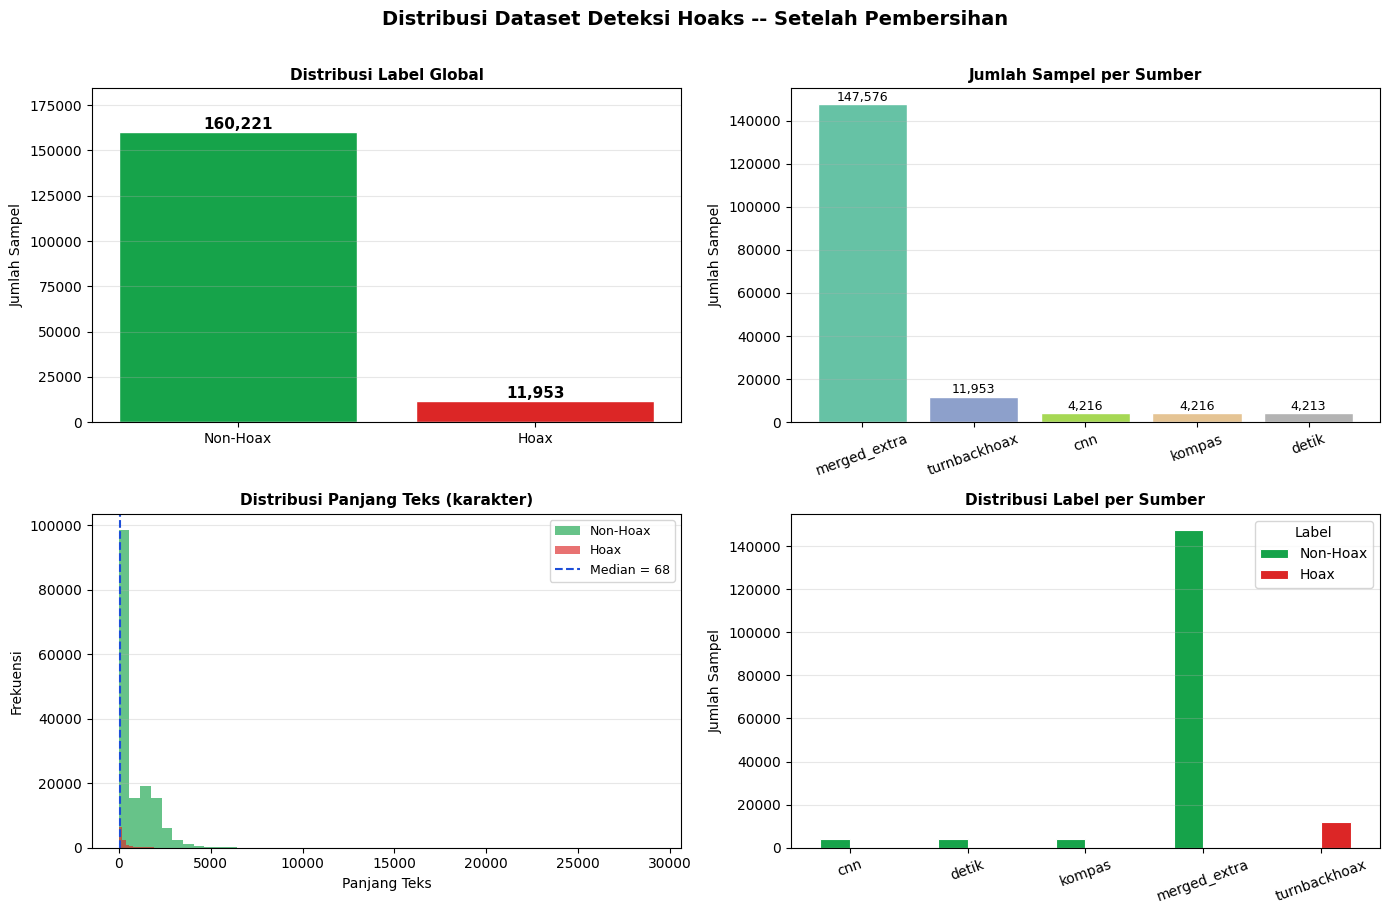

Grafik disimpan ke: distribusi_dataset.png

Statistik Panjang Teks:
count    172174.0
mean        704.0
std         978.8
min           1.0
25%          52.0
50%          68.0
75%        1306.0
max       29140.0

Rasio Hoax: 6.9%
  Train : 120,521 | Val : 25,826 | Test : 25,827

Corpus BERTopic (pra-oversampling): 120,521
Distribusi TRAIN sebelum balancing:
label
0    112154
1      8367
Distribusi TRAIN setelah balancing:
label
0    112154
1    112154


Map:   0%|          | 0/224308 [00:00<?, ? examples/s]

Map:   0%|          | 0/25826 [00:00<?, ? examples/s]

Map:   0%|          | 0/25827 [00:00<?, ? examples/s]

Train: 224,308 | Val: 25,826 | Test: 25,827
Trainer siap  — train: 224,308  |  val: 25,826

Memulai training IndoBERT...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Training selesai.
   Checkpoint terbaik : indobert_hoax_model_v3/checkpoint-3507
   Metrik terbaik (f1): 0.9905

Cache prediksi direset setelah training baru selesai.

Evaluasi VALIDATION SET


{'eval_loss': 0.009281842038035393, 'eval_accuracy': 0.9986834972508325, 'eval_precision': 0.9921656407386682, 'eval_recall': 0.9888455103179029, 'eval_f1': 0.9905027932960894, 'eval_precision_weighted': 0.9986818704302878, 'eval_recall_weighted': 0.9986834972508325, 'eval_f1_weighted': 0.9986824761944227, 'eval_runtime': 38.7361, 'eval_samples_per_second': 666.716, 'eval_steps_per_second': 1.755, 'epoch': 3.0}

Evaluasi TEST SET
{'eval_loss': 0.011937102302908897, 'eval_accuracy': 0.9984125140356991, 'eval_precision': 0.9943566591422122, 'eval_recall': 0.9827105409927496, 'eval_f1': 0.9884992987377279, 'eval_precision_weighted': 0.9984089732769063, 'eval_recall_weighted': 0.9984125140356991, 'eval_f1_weighted': 0.998408185030703, 'eval_runtime': 37.9435, 'eval_samples_per_second': 680.671, 'eval_steps_per_second': 1.792, 'epoch': 3.0}


In [14]:
# ================== SEL 14 -- Pipeline End-to-End: Load → Proses → Train → Evaluasi ==================
# Menjalankan seluruh pipeline training dalam satu cell:
#   1. Muat semua dataset dari file CSV
#   2. Bersihkan data menggunakan bangun_dataframe_training()
#   3. Visualisasi distribusi data
#   4. Bagi data stratified ke train/val/test (70/15/15)
#   5. Simpan corpus train pra-oversampling untuk BERTopic nanti
#   6. Seimbangkan kelas minoritas di training set jika diaktifkan
#   7. Tokenisasi dan konversi ke HuggingFace Dataset
#   8. Buat Trainer dengan konfigurasi training yang telah ditentukan
#   9. Jalankan training dan catat log history
#   10. Evaluasi pada validation dan test set
# Output: Model terlatih dengan metrik evaluasi lengkap.
# ==========================================================================================================

df_mentah = muat_semua_dataset(cfg)
df_bersih = bangun_dataframe_training(df_mentah)

# Visualisasi distribusi dataset
visualisasi_distribusi_dataset(df_bersih, judul_prefix="Setelah Pembersihan")

train_df, val_df, test_df = bagi_data_stratified(df_bersih, seed=cfg.seed)

# Simpan corpus pra-oversampling untuk BERTopic
train_df_pra_oversampling = train_df.copy()
print(f"\nCorpus BERTopic (pra-oversampling): {len(train_df_pra_oversampling):,}")

if cfg.balance_minority:
    train_df = seimbangkan_kelas_minoritas(train_df, seed=cfg.seed)

ds_train, ds_val, ds_test = siapkan_dataset_hf(train_df, val_df, test_df)

# Buat Trainer setelah dataset tersedia
trainer = Trainer(
    model           = model,
    args            = argumen_training,
    train_dataset   = ds_train,
    eval_dataset    = ds_val,
    data_collator   = collator_padding,
    compute_metrics = hitung_metrik,
)
print(f"Trainer siap  — train: {len(ds_train):,}  |  val: {len(ds_val):,}")

print("\n" + "="*60)
print("Memulai training IndoBERT...")
print("="*60)
hasil_training = trainer.train()

print(f"\nTraining selesai.")
print(f"   Checkpoint terbaik : {trainer.state.best_model_checkpoint}")
print(f"   Metrik terbaik (f1): {trainer.state.best_metric:.4f}")

log_history_training = list(trainer.state.log_history)

# Reset cache prediksi
_cache_prediksi: Dict[str, object] = {}
print("\nCache prediksi direset setelah training baru selesai.")

print("\n" + "="*60 + "\nEvaluasi VALIDATION SET\n" + "="*60)
metrik_val = trainer.evaluate(ds_val); print(metrik_val)

print("\n" + "="*60 + "\nEvaluasi TEST SET\n" + "="*60)
metrik_test = trainer.evaluate(ds_test); print(metrik_test)

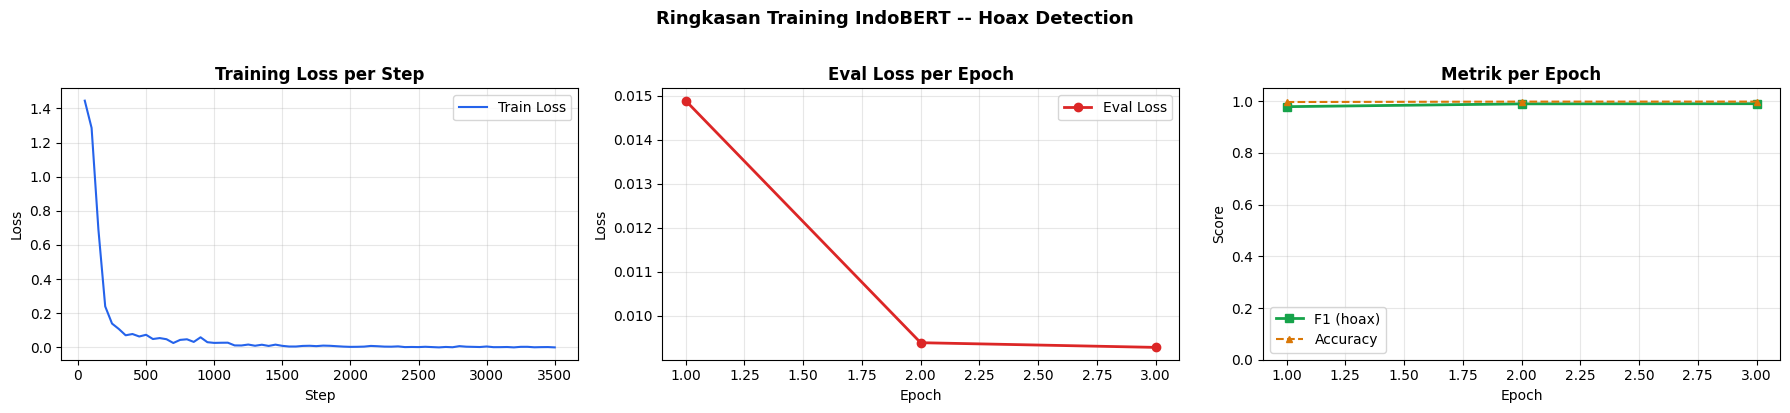

Grafik disimpan ke: kurva_training.png


In [15]:
# ================== SEL 15 -- Visualisasi Loss Curve dan Metrik per Epoch ==================
# Membuat tiga grafik untuk menganalisis proses training:
#   1. Training Loss per Step: loss saat training berlangsung
#   2. Eval Loss per Epoch: loss pada data validasi setiap epoch
#   3. Metrik per Epoch: F1-score (hoax) dan Accuracy setiap epoch
# Grafik ini membantu mendeteksi overfitting, underfitting, dan performa model akhir.
# ============================================================================================
def plot_kurva_loss(log_history: list):
    l_step, l_loss = [], []
    e_step, e_loss, e_epoch, e_f1, e_acc = [], [], [], [], []
    for entri in log_history:
        if "loss" in entri and "eval_loss" not in entri:
            l_step.append(entri["step"]); l_loss.append(entri["loss"])
        if "eval_loss" in entri:
            e_step.append(entri["step"]); e_loss.append(entri["eval_loss"])
            if "epoch"        in entri: e_epoch.append(entri["epoch"])
            if "eval_f1"      in entri: e_f1.append(entri["eval_f1"])
            if "eval_accuracy"in entri: e_acc.append(entri["eval_accuracy"])

    if not l_step and not e_step:
        print("Log history kosong."); return

    n_plot = 1 + int(bool(e_step)) + int(bool(e_f1))
    fig, axes = plt.subplots(1, n_plot, figsize=(6*n_plot, 4))
    if n_plot == 1: axes = [axes]

    if l_step:
        axes[0].plot(l_step, l_loss, color="#2563EB", lw=1.5, label="Train Loss")
        axes[0].set_title("Training Loss per Step", fontweight="bold"); axes[0].set_xlabel("Step")
        axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    if e_step:
        x, xl = (e_epoch,"Epoch") if e_epoch else (e_step,"Step")
        axes[1].plot(x, e_loss, "o-", color="#DC2626", lw=2, ms=6, label="Eval Loss")
        axes[1].set_title("Eval Loss per Epoch", fontweight="bold"); axes[1].set_xlabel(xl)
        axes[1].set_ylabel("Loss"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    if e_f1:
        x, xl = (e_epoch,"Epoch") if e_epoch else (list(range(1,len(e_f1)+1)),"Checkpoint")
        axes[2].plot(x, e_f1, "s-", color="#16A34A", lw=2, ms=6, label="F1 (hoax)")
        if e_acc:
            axes[2].plot(x, e_acc, "^--", color="#D97706", lw=1.5, ms=5, label="Accuracy")
        axes[2].set_title("Metrik per Epoch", fontweight="bold"); axes[2].set_xlabel(xl)
        axes[2].set_ylabel("Score"); axes[2].set_ylim(0, 1.05)
        axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.suptitle("Ringkasan Training IndoBERT -- Hoax Detection", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("kurva_training.png", dpi=150, bbox_inches="tight"); plt.show()
    print("Grafik disimpan ke: kurva_training.png")


plot_kurva_loss(log_history_training)


  Laporan Klasifikasi -- Validation
              precision    recall  f1-score   support

    not_hoax     0.9992    0.9994    0.9993     24033
        hoax     0.9922    0.9888    0.9905      1793

    accuracy                         0.9987     25826
   macro avg     0.9957    0.9941    0.9949     25826
weighted avg     0.9987    0.9987    0.9987     25826



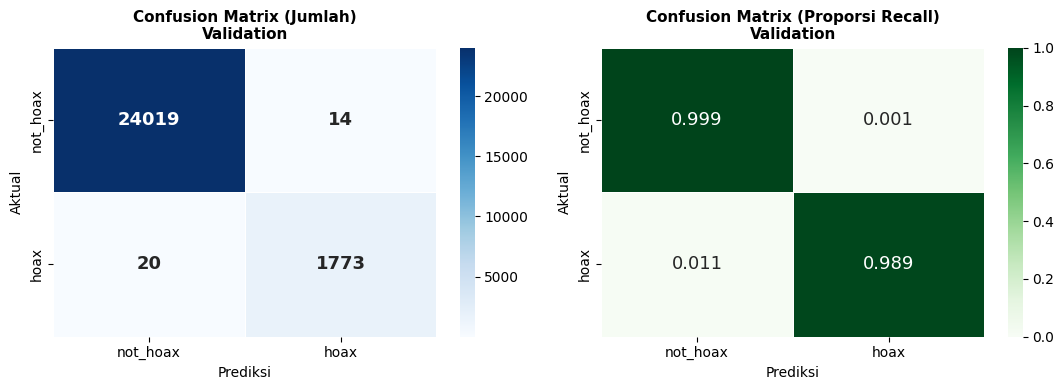

Confusion matrix disimpan ke: confusion_matrix_validation.png



  Laporan Klasifikasi -- Test
              precision    recall  f1-score   support

    not_hoax     0.9987    0.9996    0.9991     24034
        hoax     0.9944    0.9827    0.9885      1793

    accuracy                         0.9984     25827
   macro avg     0.9965    0.9911    0.9938     25827
weighted avg     0.9984    0.9984    0.9984     25827



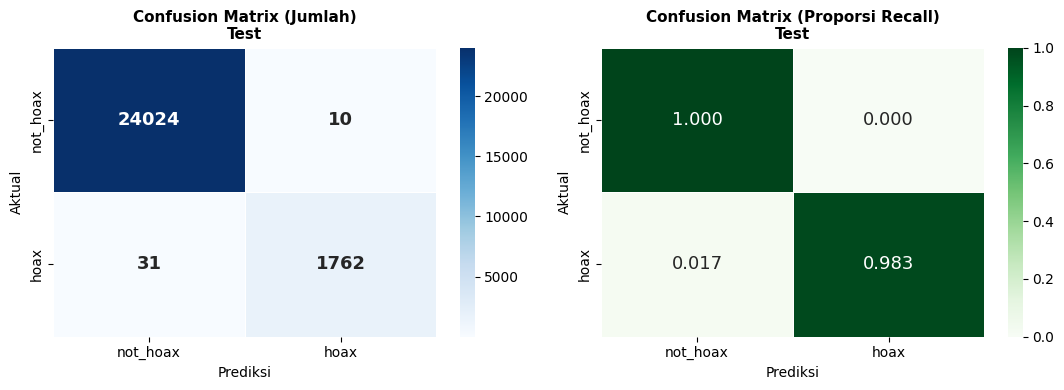

Confusion matrix disimpan ke: confusion_matrix_test.png


(array([0, 0, 0, ..., 0, 0, 0]),
 array([0, 0, 0, ..., 0, 0, 0]),
 array([[ 5.8867188, -6.0625   ],
        [ 5.9296875, -6.1015625],
        [ 5.9414062, -6.0976562],
        ...,
        [ 5.5      , -5.7617188],
        [ 4.8203125, -4.984375 ],
        [ 0.9116211, -1.0537109]], dtype=float32))

In [16]:
# ================== SEL 16 -- Laporan Klasifikasi Detail dan Confusion Matrix ==================
# Menghasilkan laporan evaluasi detail dengan:
#   1. Classification report (precision, recall, f1-score per class)
#   2. Confusion Matrix mentah (jumlah prediksi benar/salah)
#   3. Normalized Confusion Matrix (proporsi recall)
# Confusiom matrix membantu analisis error: jumlah false positive vs false negative.
# ============================================================================================

def dapatkan_prediksi(trainer: Trainer, dataset: Dataset, nama_split: str):
    if nama_split not in _cache_prediksi:
        _cache_prediksi[nama_split] = trainer.predict(dataset)
    return _cache_prediksi[nama_split]


def laporan_detail(trainer: Trainer, dataset: Dataset, nama_split: str):
    out    = dapatkan_prediksi(trainer, dataset, nama_split)
    y_asli = out.label_ids
    y_pred = np.argmax(out.predictions, axis=-1)
    kelas  = ["not_hoax", "hoax"]

    print(f"\n{'='*60}\n  Laporan Klasifikasi -- {nama_split}\n{'='*60}")
    print(classification_report(y_asli, y_pred, target_names=kelas, digits=4))

    cm      = confusion_matrix(y_asli, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=kelas, yticklabels=kelas, ax=axes[0],
                linewidths=0.5, annot_kws={"size":13,"weight":"bold"})
    axes[0].set_title(f"Confusion Matrix (Jumlah)\n{nama_split}", fontsize=11, fontweight="bold")
    axes[0].set_xlabel("Prediksi"); axes[0].set_ylabel("Aktual")

    sns.heatmap(cm_norm, annot=True, fmt=".3f", cmap="Greens",
                xticklabels=kelas, yticklabels=kelas, ax=axes[1],
                linewidths=0.5, vmin=0, vmax=1, annot_kws={"size":13})
    axes[1].set_title(f"Confusion Matrix (Proporsi Recall)\n{nama_split}", fontsize=11, fontweight="bold")
    axes[1].set_xlabel("Prediksi"); axes[1].set_ylabel("Aktual")

    plt.tight_layout()
    fname = f"confusion_matrix_{nama_split.lower().replace(' ','_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight"); plt.show()
    print(f"Confusion matrix disimpan ke: {fname}")
    return y_asli, y_pred, out.predictions


laporan_detail(trainer, ds_val,  "Validation")
laporan_detail(trainer, ds_test, "Test")

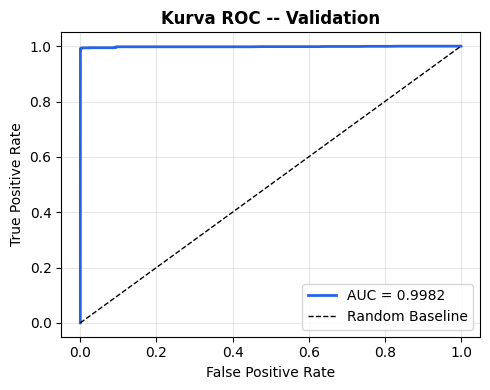

ROC curve disimpan ke: roc_curve_validation.png  |  AUC = 0.9982


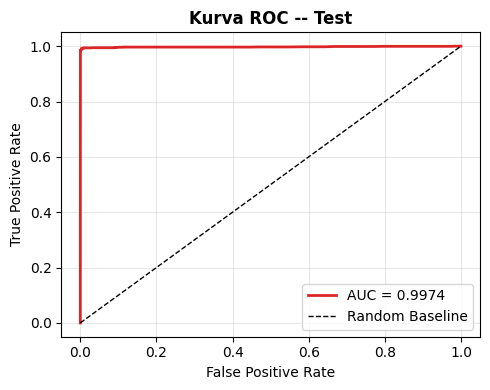

ROC curve disimpan ke: roc_curve_test.png  |  AUC = 0.9974


In [17]:
# ================== SEL 17 -- Kurva ROC dan Perhitungan AUC ==================
# Menampilkan Receiver Operating Characteristic (ROC) curve untuk setiap split.
# ROC curve menunjukkan trade-off antara True Positive Rate dan False Positive Rate
# pada berbagai threshold probabilitas.
# AUC (Area Under Curve) mengukur seberapa baik model memisahkan kelas:
#   - AUC = 1.0: Perfect classifier
#   - AUC = 0.5: Random classifier
#   - AUC > 0.7: Generally good
# ============================================================================
def plot_kurva_roc(trainer, dataset, nama_split, warna="#2563EB"):
    out   = dapatkan_prediksi(trainer, dataset, nama_split)
    probs = torch.softmax(torch.tensor(out.predictions, dtype=torch.float32), dim=-1).numpy()
    fpr, tpr, _ = roc_curve(out.label_ids, probs[:,1], pos_label=1)
    nilai_auc = auc(fpr, tpr)

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, color=warna, lw=2, label=f"AUC = {nilai_auc:.4f}")
    plt.plot([0,1],[0,1],"k--", lw=1, label="Random Baseline")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"Kurva ROC -- {nama_split}", fontsize=12, fontweight="bold")
    plt.legend(loc="lower right"); plt.grid(True, alpha=0.3); plt.tight_layout()
    fname = f"roc_curve_{nama_split.lower().replace(' ','_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight"); plt.show()
    print(f"ROC curve disimpan ke: {fname}  |  AUC = {nilai_auc:.4f}")
    return nilai_auc


auc_val  = plot_kurva_roc(trainer, ds_val,  "Validation", warna="#2563EB")
auc_test = plot_kurva_roc(trainer, ds_test, "Test",       warna="#DC2626")

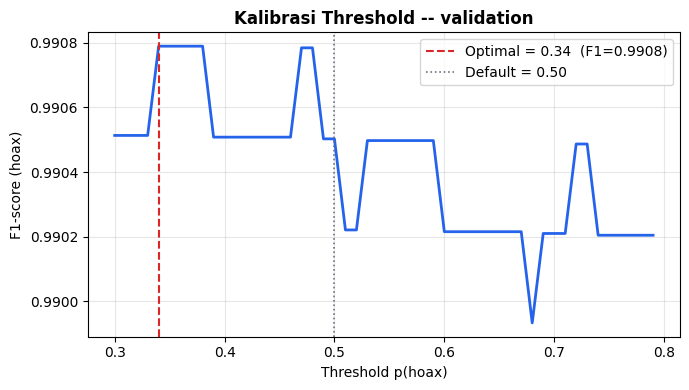

[validation] Threshold optimal : 0.34
[validation] F1 hoax @optimal  : 0.9908
[validation] F1 hoax @0.50     : 0.9905

Test F1 @0.50     : 0.9885
Test F1 @0.34 (opt): 0.9879

THRESHOLD_OPTIMAL = 0.34


In [18]:
# ================== SEL 18 -- Kalibrasi Threshold Probabilitas Optimal ==================
# Menentukan threshold optimal untuk klasifikasi berdasarkan F1-score maksimal.
# Default threshold = 0.5, tetapi optimal threshold dapat berbeda.
# Proses:
#   1. Sweep threshold dari 0.30 hingga 0.80 dengan step 0.01
#   2. Hitung F1-score untuk setiap threshold
#   3. Pilih threshold dengan F1-score tertinggi
#   4. Visualisasi untuk membandingkan F1 pada berbagai threshold
# Threshold optimal digunakan di sel inferensi untuk meningkatkan performa deteksi hoax.
# =======================================================================================
def kalibrasi_threshold(trainer, dataset, nama_split="val") -> float:
    out    = dapatkan_prediksi(trainer, dataset, nama_split)
    y_asli = out.label_ids
    probs  = torch.softmax(torch.tensor(out.predictions, dtype=torch.float32), dim=-1).numpy()
    p_hoax = probs[:,1]

    sweep    = np.arange(0.30, 0.80, 0.01)
    riwayat  = [(float(t), float(f1_score(y_asli,(p_hoax>=t).astype(int),
                                           pos_label=1, zero_division=0)))
                for t in sweep]
    t_best, f1_best = max(riwayat, key=lambda x: x[1])

    tv, fv = zip(*riwayat)
    plt.figure(figsize=(7, 4))
    plt.plot(tv, fv, color="#2563EB", lw=2)
    plt.axvline(t_best, color="#DC2626", ls="--", lw=1.5,
                label=f"Optimal = {t_best:.2f}  (F1={f1_best:.4f})")
    plt.axvline(0.5, color="#6B7280", ls=":", lw=1.2, label="Default = 0.50")
    plt.xlabel("Threshold p(hoax)"); plt.ylabel("F1-score (hoax)")
    plt.title(f"Kalibrasi Threshold -- {nama_split}", fontsize=12, fontweight="bold")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(f"kalibrasi_threshold_{nama_split}.png", dpi=150, bbox_inches="tight")
    plt.show()

    f1_def = f1_score(y_asli, (p_hoax>=0.5).astype(int), pos_label=1)
    print(f"[{nama_split}] Threshold optimal : {t_best:.2f}")
    print(f"[{nama_split}] F1 hoax @optimal  : {f1_best:.4f}")
    print(f"[{nama_split}] F1 hoax @0.50     : {f1_def:.4f}")
    return t_best


THRESHOLD_OPTIMAL = kalibrasi_threshold(trainer, ds_val, "validation")

out_test = dapatkan_prediksi(trainer, ds_test, "Test")
p_test   = torch.softmax(torch.tensor(out_test.predictions, dtype=torch.float32), dim=-1).numpy()[:,1]
y_test   = out_test.label_ids

f1_def = f1_score(y_test, (p_test>=0.5).astype(int), pos_label=1)
f1_opt = f1_score(y_test, (p_test>=THRESHOLD_OPTIMAL).astype(int), pos_label=1)
print(f"\nTest F1 @0.50     : {f1_def:.4f}")
print(f"Test F1 @{THRESHOLD_OPTIMAL:.2f} (opt): {f1_opt:.4f}")
print(f"\nTHRESHOLD_OPTIMAL = {THRESHOLD_OPTIMAL:.2f}")

## Tabel Perbandingan Multi-Threshold [A2]

Tabel Precision/Recall/F1 pada berbagai threshold untuk memilih trade-off false positive vs. false negative.

In [19]:
# ================== SEL 19 -- Tabel Perbandingan Multi-Threshold ==================
# Menampilkan tabel dengan metrik klasifikasi pada berbagai threshold.
# Tabel ini membantu memilih threshold optimal berdasarkan trade-off:
#   - Precision tinggi: Kurangi false positive (peringatan salah)
#   - Recall tinggi: Kurangi false negative (hoax terlewat)
#   - F1 seimbang: Balanced trade-off antara precision dan recall
# TP (True Positive), FP (False Positive), FN (False Negative) ditampilkan untuk insight detail.
# =======================================================================================
def tabel_perbandingan_threshold(trainer, dataset, nama_split, threshold_optimal,
                                  threshold_list=None):
    if threshold_list is None:
        threshold_list = [0.30, 0.35, 0.40, 0.45, 0.50,
                          0.55, 0.60, 0.65, 0.70, threshold_optimal]
    threshold_list = sorted(set(round(t, 2) for t in threshold_list))

    out   = dapatkan_prediksi(trainer, dataset, nama_split)
    y     = out.label_ids
    probs = torch.softmax(torch.tensor(out.predictions, dtype=torch.float32), dim=-1).numpy()
    p_h   = probs[:,1]

    baris = []
    for t in threshold_list:
        pred = (p_h >= t).astype(int)
        prec = precision_score(y, pred, pos_label=1, zero_division=0)
        rec  = recall_score(y, pred,    pos_label=1, zero_division=0)
        f1   = f1_score(y, pred,        pos_label=1, zero_division=0)
        tp   = int(((pred==1)&(y==1)).sum())
        fp   = int(((pred==1)&(y==0)).sum())
        fn   = int(((pred==0)&(y==1)).sum())
        ket  = ""
        if abs(t - 0.50) < 0.005:            ket = "<- default"
        if abs(t - threshold_optimal) < 0.005: ket = "<- OPTIMAL"
        baris.append({"Threshold": f"{t:.2f}", "Precision": f"{prec:.4f}",
                       "Recall": f"{rec:.4f}", "F1-Hoax": f"{f1:.4f}",
                       "TP": tp, "FP": fp, "FN": fn, "Keterangan": ket})

    df_t = pd.DataFrame(baris)
    print(f"\n{'='*70}\n  Tabel Perbandingan Threshold -- {nama_split}\n{'='*70}")
    print(df_t.to_string(index=False))
    print("="*70)
    return df_t


tabel_val  = tabel_perbandingan_threshold(trainer, ds_val,  "Validation", THRESHOLD_OPTIMAL)
tabel_test = tabel_perbandingan_threshold(trainer, ds_test, "Test",       THRESHOLD_OPTIMAL)


  Tabel Perbandingan Threshold -- Validation
Threshold Precision Recall F1-Hoax   TP  FP  FN Keterangan
     0.30    0.9911 0.9900  0.9905 1775  16  18           
     0.34    0.9916 0.9900  0.9908 1775  15  18 <- OPTIMAL
     0.35    0.9916 0.9900  0.9908 1775  15  18           
     0.40    0.9916 0.9894  0.9905 1774  15  19           
     0.45    0.9916 0.9894  0.9905 1774  15  19           
     0.50    0.9922 0.9888  0.9905 1773  14  20 <- default
     0.55    0.9927 0.9883  0.9905 1772  13  21           
     0.60    0.9927 0.9877  0.9902 1771  13  22           
     0.65    0.9927 0.9877  0.9902 1771  13  22           
     0.70    0.9933 0.9872  0.9902 1770  12  23           

  Tabel Perbandingan Threshold -- Test
Threshold Precision Recall F1-Hoax   TP  FP  FN Keterangan
     0.30    0.9927 0.9833  0.9880 1763  13  30           
     0.34    0.9932 0.9827  0.9879 1762  12  31 <- OPTIMAL
     0.35    0.9932 0.9827  0.9879 1762  12  31           
     0.40    0.9932 0.9827  0

In [20]:
# ================== SEL 20 -- Simpan Model IndoBERT dan Metadata ==================
# Menyimpan model terlatih, tokenizer, dan konfigurasi inferensi.
# File yang disimpan:
#   1. Model weights (pytorch_model.bin)
#   2. Model config (config.json)
#   3. Tokenizer vocab (vocab.txt, special_tokens_map.json, dll)
#   4. inference_config.json: Metadata untuk inferensi (threshold, versi library, dll)
# Output disimpan di direktori output_dir (default: "indobert_hoax_model_v3")
# =================================================================================
os.makedirs(cfg.output_dir, exist_ok=True)
trainer.model.save_pretrained(cfg.output_dir)
tokenizer.save_pretrained(cfg.output_dir)

metadata_inferensi = {
    "threshold_optimal":     float(THRESHOLD_OPTIMAL),
    "threshold_default":     0.5,
    "metric_for_best_model": "f1",
    "model_name":            cfg.model_name,
    "max_length":            cfg.max_length,
    "label2id":              label_ke_id,
    "id2label":              {str(k): v for k, v in id_ke_label.items()},
    "transformers_version":  transformers.__version__,
    "torch_version":         torch.__version__,
    "training_date":         pd.Timestamp.now().strftime("%Y-%m-%d"),
}
with open(os.path.join(cfg.output_dir, "inference_config.json"), "w",
          encoding="utf-8") as _f:
    _json.dump(metadata_inferensi, _f, indent=2, ensure_ascii=False)

print(f"Model & metadata disimpan ke: {cfg.output_dir}/")
print(f"   Best checkpoint      : {trainer.state.best_model_checkpoint}")
print(f"   THRESHOLD_OPTIMAL    : {THRESHOLD_OPTIMAL:.2f}")
print(f"   transformers_version : {transformers.__version__}")
print(f"   training_date        : {metadata_inferensi['training_date']}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model & metadata disimpan ke: indobert_hoax_model_v3/
   Best checkpoint      : indobert_hoax_model_v3/checkpoint-3507
   THRESHOLD_OPTIMAL    : 0.34
   transformers_version : 5.0.0
   training_date        : 2026-04-27


## Inferensi Multi-Paragraf (Sentence-Level + Topic)

**Tidak mengubah training classifier IndoBERT.** Semua proses adalah post-processing:
memisahkan teks menjadi paragraf dan kalimat, mengklasifikasikan setiap kalimat, mengagregasi label, dan mengekstraksi topik TF-IDF.

- **[FIX HR-1]** Menggunakan `THRESHOLD_OPTIMAL` (dari val set)
- **[FIX O2]** `torch.inference_mode()` menggantikan `torch.no_grad()`

In [21]:
# ================== SEL 21 -- Utilitas Inferensi Multi-Paragraf dan Topic Extraction ==================
# Fungsi-fungsi untuk inferensi pada teks multi-paragraf dengan detail kalimat dan ekstraksi topik.
# Fitur:
#   1. prediksi_batch(): Batch prediction dengan threshold optimal
#   2. ekstrak_topik_tfidf(): Ekstraksi topik TF-IDF per paragraf
#   3. analisis_multi_paragraf(): Analisis lengkap dokumen (doc-level, paragraph-level, sentence-level)
# Menggunakan torch.inference_mode() untuk efisiensi memori dan kecepatan inference.
# Output: JSON terstruktur dengan pemetaan risiko (high/medium/low).
# ===================================================================================================
import re
from collections import defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer

REGEX_PISAH_PARAGRAF = re.compile(r"(?:\r?\n){2,}")
REGEX_PISAH_KALIMAT  = re.compile(r'[^.!?]+(?:[.!?]+(?:[")\]]+)?)|[^.!?]+$')
REGEX_SPASI          = re.compile(r"\s+")
REGEX_TOKEN          = re.compile(r"[a-zA-Z]{3,}")

STOPWORDS_ID = {
    "yang","dan","atau","di","ke","dari","untuk","dengan","pada",
    "adalah","itu","ini","dalam","sebagai","karena","juga","agar",
    "oleh","saat","akan","telah","sudah","tidak","iya","ya","kita",
    "mereka","kami","anda","hingga","lebih","masih","dapat","bisa",
    "setelah","sebelum","tersebut","terhadap","disebut","menurut",
}


def normalisasi_teks(teks: str) -> str:
    return REGEX_SPASI.sub(" ", str(teks)).strip()


def pisahkan_paragraf(teks: str) -> List[str]:
    mentah = str(teks).strip()
    if not mentah: return []
    par = [p.strip() for p in REGEX_PISAH_PARAGRAF.split(mentah) if p.strip()]
    return par if par else [mentah]


def pisahkan_kalimat(paragraf: str) -> List[str]:
    d = normalisasi_teks(paragraf)
    if not d: return []
    kal = [m.group(0).strip() for m in REGEX_PISAH_KALIMAT.finditer(d)]
    return [k for k in kal if k] or [d]


def prediksi_batch(teks_list: List[str], ukuran_batch: int = 64) -> List[Dict]:
    if not teks_list: return []
    th = THRESHOLD_OPTIMAL if "THRESHOLD_OPTIMAL" in globals() else 0.5
    semua_probs = []
    model.eval()
    for i in range(0, len(teks_list), ukuran_batch):
        potongan = [normalisasi_teks(t) or "[EMPTY]" for t in teks_list[i:i+ukuran_batch]]
        enc = tokenizer(potongan, truncation=True, max_length=cfg.max_length,
                        padding=True, return_tensors="pt")
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.inference_mode():
            probs = torch.softmax(model(**enc).logits, dim=-1).cpu().numpy()
        semua_probs.extend(probs)

    hasil = []
    for baris in semua_probs:
        p_n, p_h = float(baris[0]), float(baris[1])
        label = "hoax" if p_h >= th else "not_hoax"
        conf  = max(p_h, p_n)
        warna = "red" if label=="hoax" else ("amber" if conf<0.70 else "green")
        hasil.append({
            "label": label,
            "probabilities": {"not_hoax": round(p_n,6), "hoax": round(p_h,6)},
            "hoax_probability": round(p_h, 6),
            "confidence":       round(conf, 6),
            "color":            warna,
            "threshold_used":   round(th, 2),
        })
    return hasil


def ekstrak_topik_tfidf(teks_par: List[str], top_k: int = 3, maks_fitur: int = 1500) -> List[Dict]:
    if not teks_par: return []
    vec = TfidfVectorizer(lowercase=True, ngram_range=(1,2), max_features=maks_fitur,
                           token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b",
                           stop_words=list(STOPWORDS_ID))
    out_t = []
    try:
        M = vec.fit_transform(teks_par); F = vec.get_feature_names_out()
        for i in range(M.shape[0]):
            br = M.getrow(i)
            if br.nnz == 0:
                tok = [t for t in REGEX_TOKEN.findall(teks_par[i].lower()) if t not in STOPWORDS_ID]
                kk  = list(dict.fromkeys(tok))[:top_k] or ["topik_umum"]
                skor = 0.0
            else:
                pas  = sorted(zip(br.indices, br.data), key=lambda x:(-x[1],F[x[0]]))[:top_k]
                kk   = [F[idx] for idx,_ in pas]
                skor = float(np.mean([v for _,v in pas])) if pas else 0.0
            out_t.append({"label": " / ".join(kk[:2]) if kk else "topik_umum",
                           "score": round(skor,6), "keywords": kk[:top_k]})
    except Exception:
        for t in teks_par:
            tok = [x for x in REGEX_TOKEN.findall(t.lower()) if x not in STOPWORDS_ID]
            kk  = list(dict.fromkeys(tok))[:top_k] or ["topik_umum"]
            out_t.append({"label": " / ".join(kk[:2]) if kk else "topik_umum",
                           "score": 0.0, "keywords": kk[:top_k]})
    return out_t


def analisis_multi_paragraf(teks: str, ukuran_batch_kalimat: int = 64) -> Dict[str,Any]:
    teks_m = str(teks).strip()
    th = THRESHOLD_OPTIMAL if "THRESHOLD_OPTIMAL" in globals() else 0.5
    if not teks_m:
        return {"document":{"label":"not_hoax","hoax_probability":0.0,"confidence":0.0,
                             "risk_level":"low","sentence_aggregate_label":"not_hoax",
                             "threshold_used":th,
                             "summary":{"paragraph_count":0,"sentence_count":0,
                                        "hoax_sentence_count":0,"not_hoax_sentence_count":0}},
                "paragraphs":[],"shared_topics":[]}

    pred_doc = prediksi_batch([teks_m], ukuran_batch=1)[0]
    par_list = pisahkan_paragraf(teks_m)
    t_kal, p_kal = [], []
    for pi, par in enumerate(par_list):
        for si, k in enumerate(pisahkan_kalimat(par)):
            t_kal.append(k); p_kal.append((pi,si))

    pred_kal = prediksi_batch(t_kal, ukuran_batch=ukuran_batch_kalimat)
    obj_par  = [{"paragraph_index":i,"text":p,"sentences":[]} for i,p in enumerate(par_list)]
    for (pi,si),tk,pred in zip(p_kal,t_kal,pred_kal):
        obj_par[pi]["sentences"].append({"sentence_index":si,"text":tk,**pred})

    topik_list = ekstrak_topik_tfidf([p["text"] for p in obj_par])
    jh = jnh = 0
    for i,op in enumerate(obj_par):
        kal = op["sentences"]
        if not kal:
            op.update({"label":"not_hoax","hoax_probability":0.0,"confidence":0.0})
        else:
            op["label"]            = "hoax" if any(k["label"]=="hoax" for k in kal) else "not_hoax"
            op["hoax_probability"] = round(max(k["hoax_probability"] for k in kal),6)
            op["confidence"]       = round(max(k["confidence"]       for k in kal),6)
            jh  += sum(1 for k in kal if k["label"]=="hoax")
            jnh += sum(1 for k in kal if k["label"]!="hoax")
        op["topic"] = topik_list[i]

    tmap = defaultdict(list)
    for p in obj_par: tmap[p["topic"]["label"]].append(p["paragraph_index"])
    topik_bersama = sorted([{"label":l,"paragraph_indices":v} for l,v in tmap.items() if len(v)>1],
                            key=lambda x:(x["paragraph_indices"][0],x["label"]))

    return {
        "document": {
            "label":                    pred_doc["label"],
            "hoax_probability":         pred_doc["hoax_probability"],
            "confidence":               pred_doc["confidence"],
            "threshold_used":           pred_doc["threshold_used"],
            "risk_level": ("high" if pred_doc["hoax_probability"]>0.98 else
                           "medium" if pred_doc["hoax_probability"]>0.60 else "low"),
            "sentence_aggregate_label": "hoax" if jh>0 else "not_hoax",
            "summary":{"paragraph_count":len(obj_par),"sentence_count":len(pred_kal),
                        "hoax_sentence_count":jh,"not_hoax_sentence_count":jnh},
        },
        "paragraphs":obj_par, "shared_topics":topik_bersama,
    }


print("Utilitas inferensi multi-paragraf siap.")
print(f"   Threshold aktif  : {THRESHOLD_OPTIMAL:.2f}")

Utilitas inferensi multi-paragraf siap.
   Threshold aktif  : 0.34


## Demo Inferensi V1

Deteksi multi-paragraf dengan threshold yang sudah dikalibrasi.

In [22]:
# ================== SEL 22 -- Demo Inferensi Multi-Paragraf ==================
# Contoh penggunaan fungsi analisis_multi_paragraf() pada teks multi-paragraf.
# Mendemonstrasikan:
#   1. Parsing paragraf dan kalimat
#   2. Klasifikasi setiap kalimat dengan threshold optimal
#   3. Agregasi label per paragraf
#   4. Ekstraksi topik TF-IDF per paragraf
#   5. Identifikasi topik bersama antar-paragraf
# =============================================================================
contoh_teks = """
Beredar unggahan media sosial yang menyebut pemerintah membagikan bantuan tunai langsung tanpa syarat lewat tautan tertentu. Banyak akun meminta warga mengisi data pribadi dan OTP agar dana cair hari itu juga.

Kementerian terkait kemudian merilis klarifikasi bahwa informasi tersebut tidak benar dan meminta masyarakat tidak membagikan tautan yang tidak berasal dari kanal resmi. Warga diminta cek pengumuman hanya lewat situs resmi pemerintah.

Sejumlah komentar pengguna juga menuliskan pengalaman bahwa tautan serupa berujung pada permintaan data rekening. Pakar keamanan digital menyarankan verifikasi sumber sebelum menyebarkan pesan berantai.
"""

hasil = analisis_multi_paragraf(contoh_teks, ukuran_batch_kalimat=64)

print("=" * 60 + "\nHASIL DOKUMEN:")
for k, v in hasil["document"].items():
    if k != "summary": print(f"  {k:30s}: {v}")
print(f"  {'summary':30s}: {hasil['document']['summary']}")
print("=" * 60)

for par in hasil["paragraphs"]:
    print(f"\n[Paragraf {par['paragraph_index']}]  label={par['label']}")
    print(f"  Topik : {par['topic']['label']} (score={par['topic']['score']})")
    for k in par["sentences"]:
        print(f"  . ({k['sentence_index']}) {k['label']} | p_hoax={k['hoax_probability']:.4f} | conf={k['confidence']:.4f}")

if hasil["shared_topics"]:
    print("\nTopik Bersama:", hasil["shared_topics"])

HASIL DOKUMEN:
  label                         : hoax
  hoax_probability              : 0.988949
  confidence                    : 0.988949
  threshold_used                : 0.34
  risk_level                    : high
  sentence_aggregate_label      : hoax
  summary                       : {'paragraph_count': 3, 'sentence_count': 6, 'hoax_sentence_count': 6, 'not_hoax_sentence_count': 0}

[Paragraf 0]  label=hoax
  Topik : akun / akun meminta (score=0.14461)
  . (0) hoax | p_hoax=0.9999 | conf=0.9999
  . (1) hoax | p_hoax=1.0000 | conf=1.0000

[Paragraf 1]  label=hoax
  Topik : resmi / bahwa informasi (score=0.196977)
  . (0) hoax | p_hoax=0.9999 | conf=0.9999
  . (1) hoax | p_hoax=0.9997 | conf=0.9997

[Paragraf 2]  label=hoax
  Topik : bahwa tautan / berantai (score=0.1591)
  . (0) hoax | p_hoax=0.9979 | conf=0.9979
  . (1) hoax | p_hoax=0.9931 | conf=0.9931


## No-Regression Guarantee

1. **Training core tidak diubah secara semantik** -- alur `70/15/15 split -> balancing hanya di train -> classifier biner IndoBERT` identik dengan baseline.
2. **BERTopic murni post-processing** -- tidak menyentuh bobot model classifier.
3. **Semua perbaikan bersifat additive** -- bug fix + optimasi tanpa mengganti arsitektur.
4. **Threshold dikalibrasi dari val set** -- test set tidak disentuh sampai evaluasi akhir.

## BERTopic Topic Modeling (Post-Training)

Berjalan **setelah** training classifier selesai. Tidak masuk ke loop training dan tidak mengubah bobot IndoBERT.

**Konfigurasi aktif:**
- Corpus = `train_df_pra_oversampling` (sebelum oversampling)
- Embedding = `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`
- UMAP + HDBSCAN dipakai untuk reduksi dimensi dan clustering berbasis densitas
- `NR_TOPIK = 80` sebagai target topic reduction BERTopic
- `calculate_probabilities=False` untuk mengurangi beban fit
- Guided topic modeling memakai `seed_topic_list` dari kategori tematik

Evaluasi tambahan pada versi DBCS memakai DBCV sebagai pengganti formal elbow method untuk clustering berbasis densitas.


In [23]:
# ================== SEL 23 -- Import Library BERTopic dan Dependensi ==================
# Mengimpor library untuk Topic Modeling menggunakan BERTopic.
# BERTopic menggunakan pipeline berikut:
#   1. Embedding: SentenceTransformer untuk mengubah teks menjadi vektor
#   2. Dimensionality Reduction: UMAP untuk menurunkan dimensi embedding
#   3. Clustering: HDBSCAN untuk mengelompokkan dokumen
#   4. Vectorizer: CountVectorizer untuk ekstraksi kata-kata penting
# ====================================================================================
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
import re as _re

STOPWORDS_BERTOPIC_ID = {
    "yang", "dan", "atau", "di", "ke", "dari", "untuk", "dengan", "pada",
    "adalah", "itu", "ini", "dalam", "sebagai", "karena", "juga", "agar",
    "oleh", "saat", "akan", "telah", "sudah", "tidak", "iya", "ya", "kita",
    "mereka", "kami", "anda", "hingga", "lebih", "masih", "dapat", "bisa",
    "setelah", "sebelum", "tersebut", "terhadap", "disebut", "menurut",
    "para", "dalam", "pihak", "bagi", "jadi", "kata", "ujar", "ungkap",
    "yakni", "serta", "karena", "sudah", "belum", "akan", "langsung",
}

STOPWORDS_BERTOPIC_EN = {
    "the", "and", "or", "of", "to", "in", "on", "for", "with", "by",
    "from", "at", "as", "is", "are", "was", "were", "be", "been", "being",
    "this", "that", "these", "those", "it", "its", "into", "about", "than",
    "after", "before", "not", "no", "yes", "you", "your", "their", "they",
    "we", "our", "us", "more", "most", "can", "could", "would", "should",
}

STOPWORDS_BERTOPIC = STOPWORDS_BERTOPIC_ID | STOPWORDS_BERTOPIC_EN
CUSTOM_NOISE_WORDS = {
    "extra", "com", "news", "gra", "bahasa", "saja", "baru", "per",
    "get", "day", "war", "red", "tbk", "archive", "arsip",
}
STOPWORDS_BERTOPIC = STOPWORDS_BERTOPIC | CUSTOM_NOISE_WORDS

BOILERPLATE_BERTOPIC = [
    "baca berita sedikit iklan klik sini",
    "scroll bawah melanjutkan membaca",
    "baca berita",
    "klik di sini",
    "klik disini",
    "klik sini",
    "scroll bawah",
    "melanjutkan membaca",
    "selengkapnya",
    "lihat juga",
    "baca juga",
    "simak juga",
    "pilihan editor",
    "artikel selengkapnya",
    "baca selengkapnya",
    "sedikit iklan",
]

REGEX_URL_BERTOPIC = _re.compile(r"https?://\S+|www\.\S+")
REGEX_ANGKA_BERTOPIC = _re.compile(r"\b\d+(?:[\.,:/-]\d+)*\b")
REGEX_SIMBOL_BERTOPIC = _re.compile(r"[^a-z\s]")
REGEX_SPASI_BERTOPIC = _re.compile(r"\s+")


def kandidat_teks_bertopic(baris: pd.Series) -> List[str]:
    kandidat: List[str] = []
    for kol in ["summary", "isi_berita"]:
        nilai = baris.get(kol, "")
        if isinstance(nilai, str) and nilai.strip():
            kandidat.append(nilai.strip())
    return kandidat


def preprocess_teks_bertopic(teks: str) -> str:
    teks = str(teks or "").lower().strip()
    if not teks:
        return ""

    teks = REGEX_URL_BERTOPIC.sub(" ", teks)
    for frase in BOILERPLATE_BERTOPIC:
        teks = teks.replace(frase, " ")

    teks = REGEX_ANGKA_BERTOPIC.sub(" ", teks)
    teks = REGEX_SIMBOL_BERTOPIC.sub(" ", teks)
    teks = REGEX_SPASI_BERTOPIC.sub(" ", teks).strip()
    if not teks:
        return ""

    token_bersih = [
        tok for tok in teks.split(" ")
        if tok and tok not in STOPWORDS_BERTOPIC and len(tok) > 2
    ]
    return " ".join(token_bersih).strip()


def siapkan_corpus_bertopic(df_sumber: pd.DataFrame) -> List[str]:
    corpus: List[str] = []
    for _, baris in df_sumber.iterrows():
        teks_final = ""
        for teks_sumber in kandidat_teks_bertopic(baris):
            teks_final = preprocess_teks_bertopic(teks_sumber)
            if teks_final:
                break
        corpus.append(teks_final if teks_final else "topik umum")
    return corpus

print("Import BERTopic stack selesai.")

Import BERTopic stack selesai.


In [24]:
# ================== SEL 24 -- Fit BERTopic pada Corpus Training (Post-Training) ==================
# Menjalankan Topic Modeling menggunakan BERTopic pada corpus training.
# Tahapan:
#   1. Embedding dokumen menggunakan SentenceTransformer (multilingual model)
#   2. Reduce dimensionalitas dengan UMAP
#   3. Cluster dokumen dengan HDBSCAN
#   4. Ekstraksi kata-kata penting dengan CountVectorizer
# Guided Topic Modeling (jika AKTIFKAN_GUIDED=True): Menggunakan seed_topic_list untuk panduan topik awal.
# Output: model_topik, id_topik (topik per dokumen), prob_topik (probabilitas topik).
# =====================================================================================================

if not AKTIFKAN_BERTOPIC:
    model_topik = None; dokumen_topik = []; id_topik = []; prob_topik = None
    print("AKTIFKAN_BERTOPIC=False, proses BERTopic dilewati.")
else:
    # Gunakan corpus khusus BERTopic: summary -> isi_berita, lalu preprocessing terpisah
    dokumen_topik = siapkan_corpus_bertopic(train_df_pra_oversampling)
    if MAKS_DOKUMEN_BERTOPIC and len(dokumen_topik) > MAKS_DOKUMEN_BERTOPIC:
        rng = random.Random(SEED_BERTOPIC)
        dokumen_topik = rng.sample(dokumen_topik, MAKS_DOKUMEN_BERTOPIC)

    print(f"Dokumen BERTopic (pra-oversampling): {len(dokumen_topik):,}")
    dev = "cuda" if torch.cuda.is_available() else "cpu"
    if torch.cuda.is_available():
        print(f"VRAM sebelum encode: {torch.cuda.memory_allocated()/1e6:.1f} MB")

    # Normalize ringan setelah preprocessing untuk menjaga konsistensi input embedding
    dokumen_topik_clean = [
        REGEX_SPASI_BERTOPIC.sub(" ", str(d)).strip() for d in dokumen_topik
    ]

    embedder = SentenceTransformer(MODEL_EMBEDDING_BERTOPIC, device=dev)
    try:
        emb = embedder.encode(
            dokumen_topik_clean, batch_size=UKURAN_BATCH_EMBED,
            show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True,
        )
    except ValueError as _e:
        print(f"[WARN] Encoding error: {_e}, retry dengan escape mode...")
        dokumen_topik_clean = [REGEX_SPASI_BERTOPIC.sub(" ", str(d)).strip() for d in dokumen_topik]
        emb = embedder.encode(
            dokumen_topik_clean, batch_size=UKURAN_BATCH_EMBED,
            show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True,
        )
    print(f"Shape embeddings: {emb.shape}")

    # Hapus embedder segera setelah encoding untuk menghemat VRAM
    del embedder; gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print(f"VRAM setelah hapus embedder: {torch.cuda.memory_allocated()/1e6:.1f} MB")

    umap_m = UMAP(n_neighbors=30, n_components=5, min_dist=0.1, metric="cosine",
                   random_state=SEED_BERTOPIC, low_memory=True)
    hdb_m  = HDBSCAN(min_cluster_size=30, metric="euclidean",
                      cluster_selection_method="eom", prediction_data=True)
    vec_m  = CountVectorizer(
        ngram_range=(1,2),
        min_df=10,
        max_df=0.8,
        stop_words=sorted(STOPWORDS_BERTOPIC),
    )

    # Fit BERTopic dengan guided topic modeling jika diaktifkan
    model_topik = BERTopic(
        language                 = "multilingual",
        calculate_probabilities  = BERTOPIC_HITUNG_PROB,
        nr_topics                = NR_TOPIK,
        seed_topic_list          = daftar_tema_utama if AKTIFKAN_GUIDED else None,
        verbose                  = True,
        embedding_model          = None,
        umap_model               = umap_m,
        hdbscan_model            = hdb_m,
        vectorizer_model         = vec_m,
    )
    id_topik, prob_topik = model_topik.fit_transform(dokumen_topik_clean, emb)

    jumlah_topic_sebelum_merge = len(model_topik.get_topics())
    print("Jumlah topic sebelum merge:", jumlah_topic_sebelum_merge)

    # ================== MERGE TOPIC (STEP 9.5 - CONSERVATIVE) ==================
    topics_to_merge = [
        [3, 19],   # COVID core
        [20, 65],  # Obat / medical claim
        [10, 68],  # Pemerintahan / menteri
        [27, 67],  # Korupsi / suap
    ]

    print("\n[INFO] Melakukan merge topic konservatif...")

    try:
        model_topik.merge_topics(
            dokumen_topik_clean,
            topics_to_merge=topics_to_merge
        )
        if hasattr(model_topik, "topics_") and model_topik.topics_ is not None:
            id_topik = list(model_topik.topics_)
        print("[SUCCESS] Merge topic berhasil dilakukan.")
    except Exception as e:
        print("[ERROR] Gagal merge topic:", e)

    jumlah_topic_setelah_merge = len(model_topik.get_topics())
    print("Jumlah topic setelah merge:", jumlah_topic_setelah_merge)

    info = model_topik.get_topic_info()
    n_valid = len(info[info["Topic"] != -1])
    print(f"\nBERTopic selesai.")
    print(f"   Topik valid : {n_valid}")
    print(f"   Outlier (-1): {sum(1 for t in id_topik if t==-1):,}")
    print("\n10 topik teratas:")
    print(info.head(10).to_string(index=False))

Dokumen BERTopic (pra-oversampling): 120,521
VRAM sebelum encode: 1347.6 MB


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Shape embeddings: (120521, 384)


2026-04-27 06:19:30,256 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


VRAM setelah hapus embedder: 1347.6 MB


2026-04-27 06:32:48,357 - BERTopic - Dimensionality - Completed ✓
2026-04-27 06:32:48,364 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-27 06:33:07,994 - BERTopic - Cluster - Completed ✓
2026-04-27 06:33:07,995 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-27 06:33:11,329 - BERTopic - Representation - Completed ✓
2026-04-27 06:33:11,331 - BERTopic - Topic reduction - Reducing number of topics
2026-04-27 06:33:11,512 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-27 06:33:15,758 - BERTopic - Representation - Completed ✓
2026-04-27 06:33:15,786 - BERTopic - Topic reduction - Reduced number of topics from 631 to 80


Jumlah topic sebelum merge: 80

[INFO] Melakukan merge topic konservatif...
[SUCCESS] Merge topic berhasil dilakukan.
Jumlah topic setelah merge: 76

BERTopic selesai.
   Topik valid : 75
   Outlier (-1): 48,115

10 topik teratas:
 Topic  Count                                        Name                                                                                                     Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     


[Visualisasi Topik] Total dokumen analisis utama: 53,786
  Dokumen noise (Topik Noise (Topic 0)): 18,620 [disimpan, tidak divisualisasikan]
Sampling 2500 dokumen (stratified by label)...
  Setelah sampling: 2,500 dokumen
    - Hoax: 1,250
    - Non-Hoax: 1,250


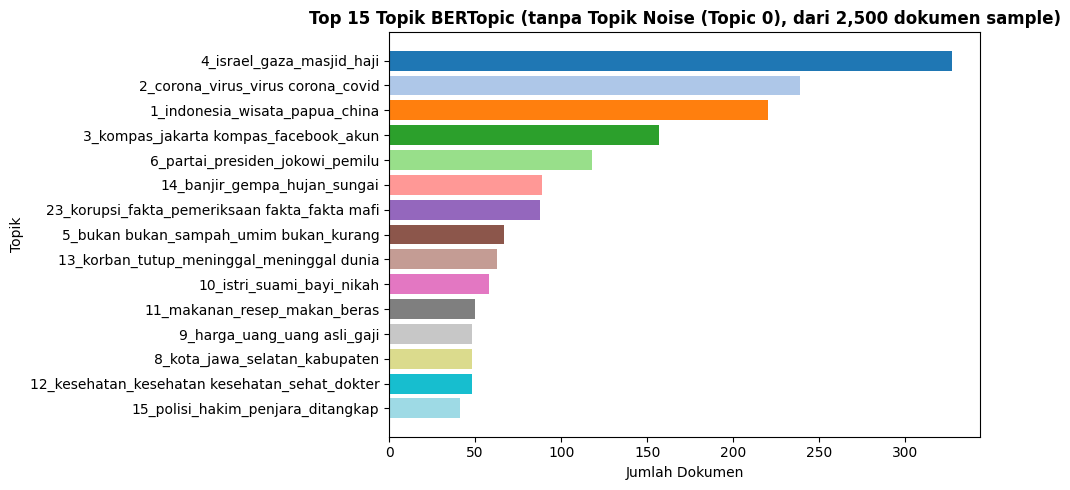

✓ Grafik distribusi topik disimpan: distribusi_topik_bertopic.png


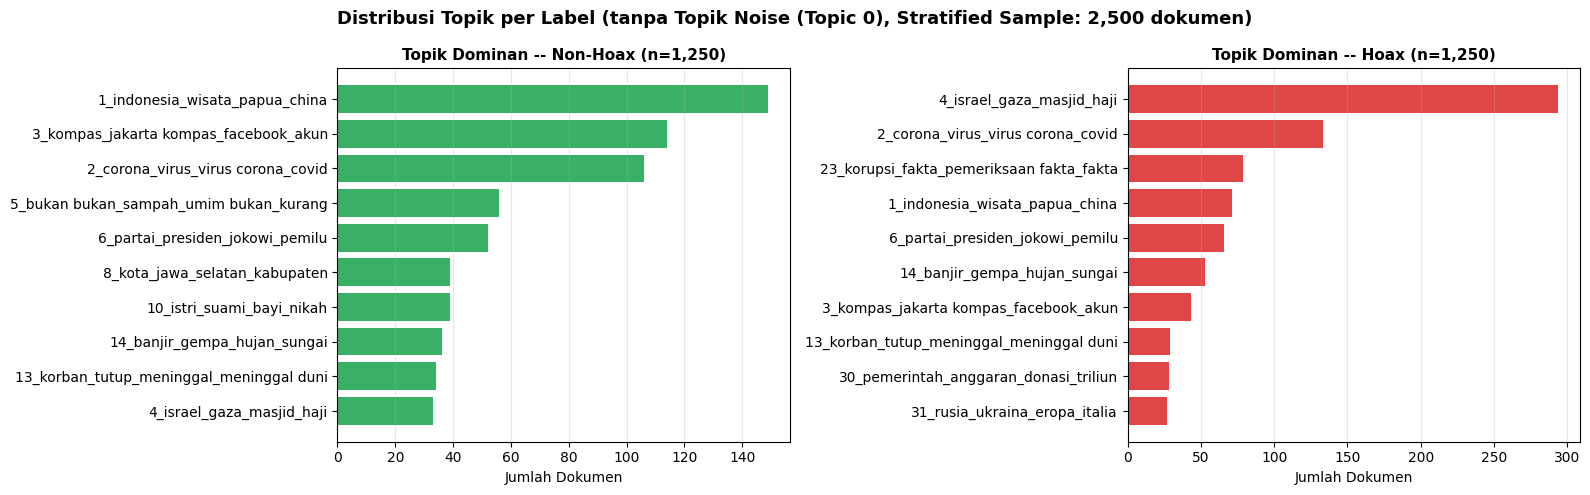

✓ Analisis topik per label disimpan: topik_per_label.png


In [25]:
# ================== SEL 25 -- Visualisasi Topik dan Analisis per Label ==================
# Membuat visualisasi distribusi topik dari BERTopic:
#   1. Grafik Top-N topik berdasarkan jumlah dokumen (dari sample 2500)
#   2. Analisis topik dominan per label (hoax vs non-hoax)
# Memberikan insights tentang topik yang sering dikaitkan dengan hoax vs non-hoax.
# Batasan dokumen untuk visualisasi: 2500 dokumen (stratified sampling untuk menjaga proporsi label)
# =======================================================================================
if AKTIFKAN_BERTOPIC and model_topik is not None:
    TOPIK_NOISE_ID = globals().get("TOPIK_NOISE_ID", 0)
    LABEL_TOPIK_NOISE = globals().get("LABEL_TOPIK_NOISE", "Topik Noise (Topic 0)")
    info_viz   = model_topik.get_topic_info()
    info_viz.loc[info_viz["Topic"] == TOPIK_NOISE_ID, "Name"] = LABEL_TOPIK_NOISE
    info_valid = info_viz[info_viz["Topic"] != -1].copy()
    info_valid_main = info_valid[info_valid["Topic"] != TOPIK_NOISE_ID].copy()

    # Siapkan data untuk visualisasi dengan batasan 2500 dokumen
    df_analisis = train_df_pra_oversampling[["text","label"]].copy()
    n_cocok = min(len(df_analisis), len(id_topik))
    df_analisis = df_analisis.iloc[:n_cocok].copy()
    df_analisis["topic_id"] = id_topik[:n_cocok]
    df_analisis = df_analisis[df_analisis["topic_id"] != -1].copy()
    peta_nama_semua = dict(zip(info_valid["Topic"], info_valid["Name"]))
    peta_nama_semua[TOPIK_NOISE_ID] = LABEL_TOPIK_NOISE
    df_analisis["topic_name"] = df_analisis["topic_id"].map(peta_nama_semua)
    jumlah_noise_dokumen = int((df_analisis["topic_id"] == TOPIK_NOISE_ID).sum())
    df_analisis = df_analisis[df_analisis["topic_id"] != TOPIK_NOISE_ID].copy()

    # Stratified sampling untuk visualisasi (max 2500 dokumen)
    MAKS_DOKUMEN_VIZ = 2500
    print(f"\n[Visualisasi Topik] Total dokumen analisis utama: {len(df_analisis):,}")
    print(f"  Dokumen noise ({LABEL_TOPIK_NOISE}): {jumlah_noise_dokumen:,} [disimpan, tidak divisualisasikan]")
    if len(df_analisis) > MAKS_DOKUMEN_VIZ:
        print(f"Sampling {MAKS_DOKUMEN_VIZ} dokumen (stratified by label)...")
        # Stratified sampling: pertahankan proporsi hoax:non-hoax menggunakan groupby
        sample_hoax = df_analisis[df_analisis["label"] == 1].sample(
            n=min(len(df_analisis[df_analisis["label"] == 1]), MAKS_DOKUMEN_VIZ // 2),
            random_state=42
        )
        sample_non_hoax = df_analisis[df_analisis["label"] == 0].sample(
            n=min(len(df_analisis[df_analisis["label"] == 0]), MAKS_DOKUMEN_VIZ // 2),
            random_state=42
        )
        df_analisis = pd.concat([sample_hoax, sample_non_hoax], ignore_index=True)
        print(f"  Setelah sampling: {len(df_analisis):,} dokumen")
        print(f"    - Hoax: {len(df_analisis[df_analisis['label'] == 1]):,}")
        print(f"    - Non-Hoax: {len(df_analisis[df_analisis['label'] == 0]):,}")

    # Plot 1: Top-N topik berdasarkan jumlah dokumen (dari sample)
    if len(df_analisis) > 0 and len(info_valid_main) > 0:
        peta_nama = dict(zip(info_valid_main["Topic"], info_valid_main["Name"]))
        df_analisis["topic_name"] = df_analisis["topic_id"].map(peta_nama)

        # Hitung distribusi topik dari sample
        topic_counts = df_analisis["topic_name"].value_counts()
        top_n = min(15, len(topic_counts))
        top_topics = topic_counts.head(top_n)

        plt.figure(figsize=(10, max(5, top_n * 0.3)))
        plt.barh(top_topics.index.str[:45], top_topics.values,
                  color=plt.cm.tab20(np.linspace(0,1,len(top_topics))))
        plt.xlabel("Jumlah Dokumen"); plt.ylabel("Topik")
        plt.title(f"Top {top_n} Topik BERTopic (tanpa {LABEL_TOPIK_NOISE}, dari {len(df_analisis):,} dokumen sample)",
                  fontsize=12, fontweight="bold")
        plt.gca().invert_yaxis(); plt.tight_layout()
        plt.savefig("distribusi_topik_bertopic.png", dpi=150, bbox_inches="tight")
        plt.show()
        print(f"✓ Grafik distribusi topik disimpan: distribusi_topik_bertopic.png")

        # Plot 2: Analisis topik per label hoax/non-hoax
        top_k_a = min(10, len(info_valid_main))
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        fig.suptitle(f"Distribusi Topik per Label (tanpa {LABEL_TOPIK_NOISE}, Stratified Sample: {len(df_analisis):,} dokumen)",
                     fontsize=13, fontweight="bold")

        for ax, lbl, judul, warna in [
            (axes[0], 0, "Topik Dominan -- Non-Hoax", "#16A34A"),
            (axes[1], 1, "Topik Dominan -- Hoax",     "#DC2626"),
        ]:
            subset = df_analisis[df_analisis["label"]==lbl]
            if len(subset) == 0:
                ax.text(0.5, 0.5, "Tidak ada data", ha="center"); continue
            hitung = subset["topic_name"].value_counts().head(top_k_a)
            ax.barh(hitung.index.str[:40], hitung.values, color=warna, alpha=0.85)
            ax.set_title(f"{judul} (n={len(subset):,})", fontsize=11, fontweight="bold")
            ax.set_xlabel("Jumlah Dokumen")
            ax.invert_yaxis(); ax.grid(axis="x", alpha=0.3)

        plt.tight_layout()
        plt.savefig("topik_per_label.png", dpi=150, bbox_inches="tight")
        plt.show()
        print(f"✓ Analisis topik per label disimpan: topik_per_label.png")
else:
    print("Model BERTopic belum tersedia, visualisasi dilewati.")

## Evaluasi BERTopic dan c-TF-IDF [SEL 25b]

Menampilkan hasil kuantitatif topic modeling:
- Jumlah topik valid, topic noise, dan persentase outlier
- Distribusi dokumen per topik
- Top-10 kata per topik beserta skor c-TF-IDF
- Coherence score sebagai pelengkap kualitas representasi topik
- DBCV (Density-Based Clustering Validation) untuk kualitas cluster HDBSCAN
- Topic diversity/exclusivity dan coverage keyword dari hasil c-TF-IDF
- Ekspor CSV untuk lampiran skripsi

Elbow method klasik tidak digunakan karena pipeline memakai BERTopic + UMAP + HDBSCAN, bukan KMeans/inertia. DBCV lebih sesuai untuk mengevaluasi cluster berbasis densitas; coherence tetap dipakai hanya untuk membaca kualitas representasi kata topik.


  Evaluasi c-TF-IDF BERTopic
Topik valid utama : 74
Topik noise       : 1 (Topik Noise (Topic 0))
Total dokumen     : 120,521
Dokumen noise     : 18,620
Dokumen outlier   : 48,115  (39.9%)

Distribusi Dokumen per Topik (analisis utama)
 Topic  Count                                                  Name
     1   5722                        1_indonesia_wisata_papua_china
     2   5465                     2_corona_virus_virus corona_covid
     3   5060                 3_kompas_jakarta kompas_facebook_akun
     4   2465                             4_israel_gaza_masjid_haji
     5   2414                5_bukan bukan_sampah_umim bukan_kurang
     6   2031                       6_partai_presiden_jokowi_pemilu
     7   1490                        7_minggu_tanggal_pekan_oktober
     8   1481                         8_kota_jawa_selatan_kabupaten
     9   1411                           9_harga_uang_uang asli_gaji
    10   1365                             10_istri_suami_bayi_nikah
    11   1327   

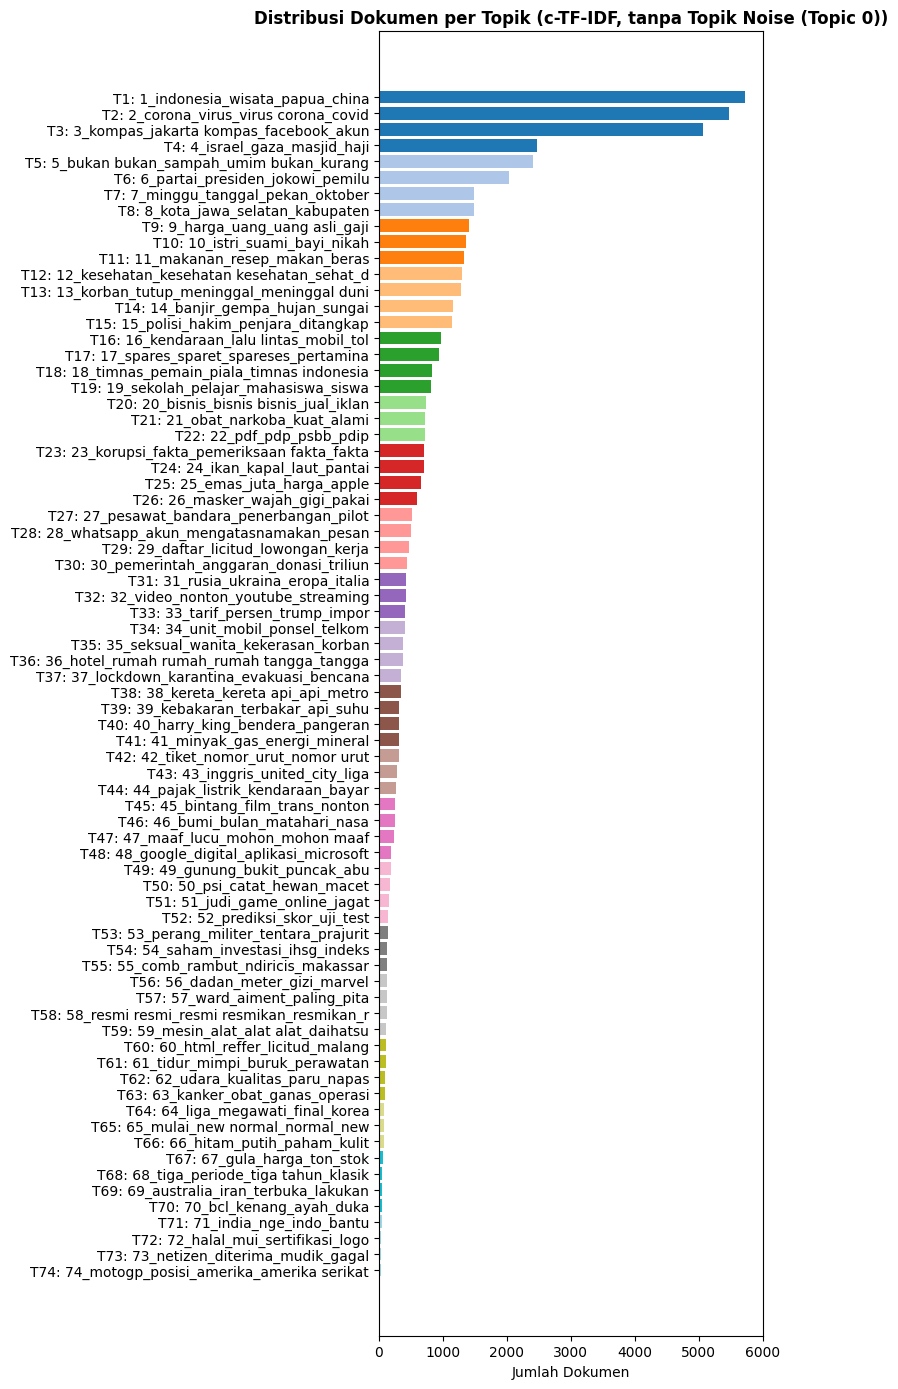

Grafik disimpan: ctfidf_distribusi_topik.png

  MAPPING: Topic ID → Kategori
  Topic  0 → Topik Noise (Topic 0)               | Top words: covid, suara, covid covid, nasional nasional, malang
  Topic  1 → Topik Umum                          | Top words: indonesia, wisata, papua, china, yogyakarta
  Topic  2 → Kesehatan                           | Top words: corona, virus, virus corona, covid, positif
  Topic  3 → Topik Umum                          | Top words: kompas, jakarta kompas, facebook, akun, akun facebook
  Topic  4 → Internasional                       | Top words: israel, gaza, masjid, haji, islam
  Topic  5 → Lingkungan & Energi                 | Top words: bukan bukan, sampah, umim bukan, kurang, tiada
  Topic  6 → Politik                             | Top words: partai, presiden, jokowi, pemilu, demokrat
  Topic  7 → Topik Umum                          | Top words: minggu, tanggal, pekan, oktober, malam
  Topic  8 → Topik Umum                          | Top words: kota, j

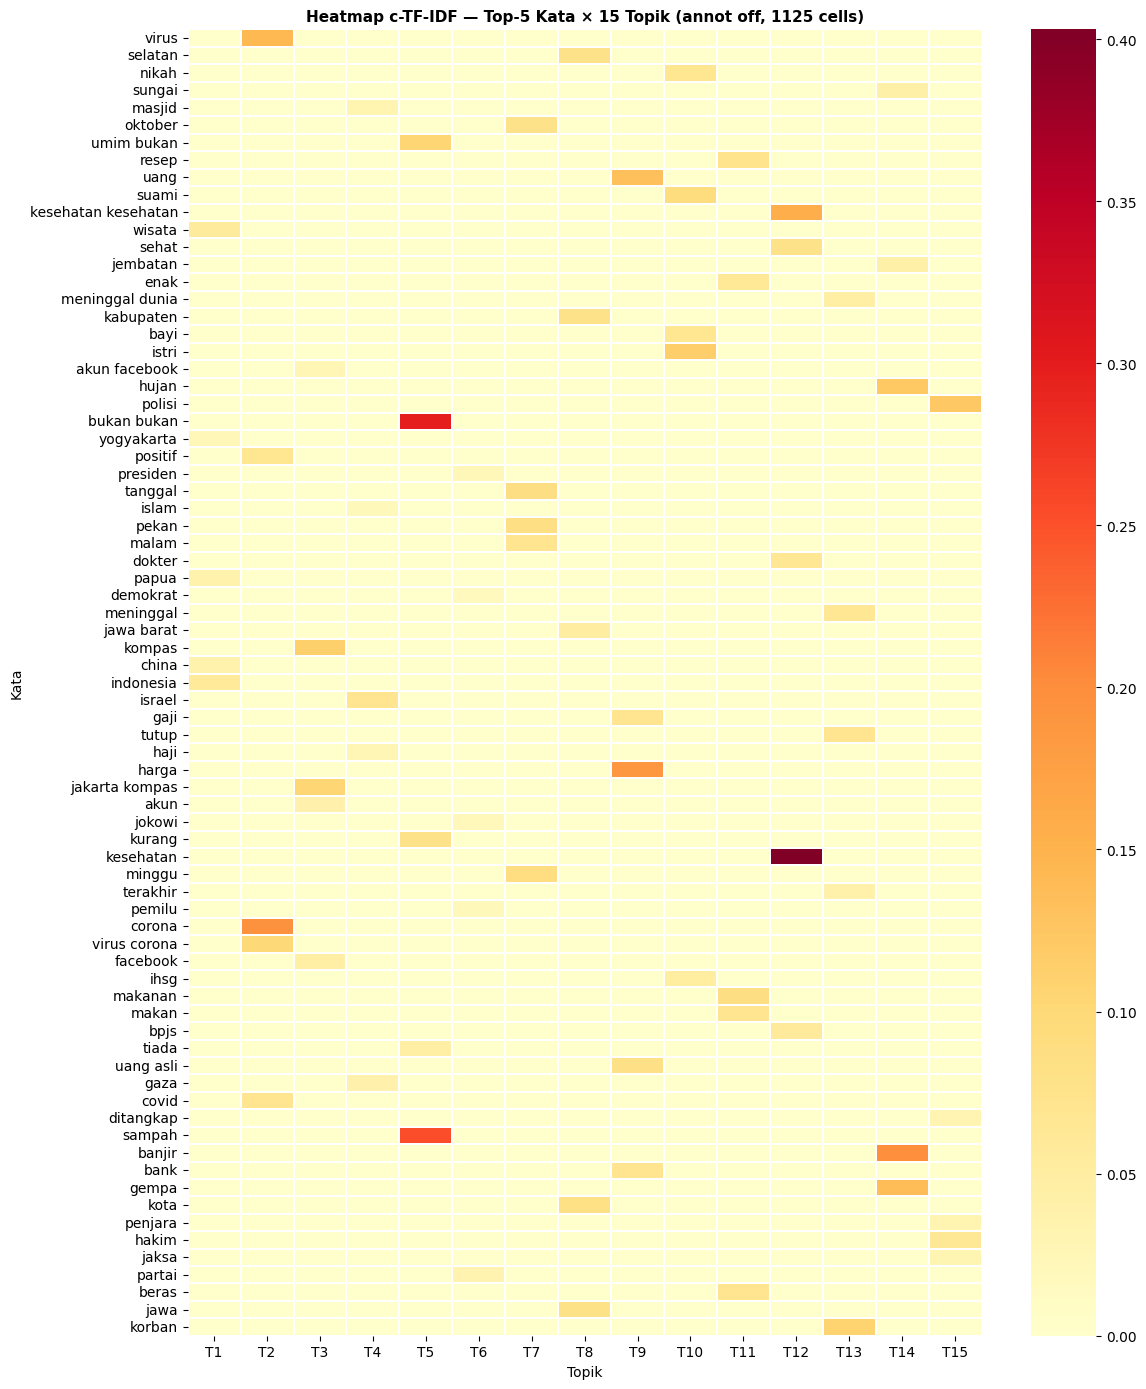

Heatmap c-TF-IDF disimpan: ctfidf_heatmap.png


In [26]:
# ================== SEL 26 -- Evaluasi c-TF-IDF BERTopic (OOM-Safe) ==================
# Menampilkan evaluasi kuantitatif Topic Modeling:
#   1. Statistik (topik valid, outlier percentage)
#   2. Distribusi dokumen per topik
#   3. Kata-kata penting per topik dengan skor c-TF-IDF
#   4. Mapping topik ke kategori (berdasarkan keyword overlap)
#   5. Heatmap c-TF-IDF dengan OOM-safe optimizations
#   6. Export ke CSV untuk analisis lebih lanjut
# Special: Kategori mapping menggunakan PETA_KATEGORI_SHARED untuk sinkronisasi dengan backend.
# =======================================================================================
if AKTIFKAN_BERTOPIC and model_topik is not None:
    TOPIK_NOISE_ID = globals().get("TOPIK_NOISE_ID", 0)
    LABEL_TOPIK_NOISE = globals().get("LABEL_TOPIK_NOISE", "Topik Noise (Topic 0)")
    info_topik      = model_topik.get_topic_info()
    info_topik.loc[info_topik["Topic"] == TOPIK_NOISE_ID, "Name"] = LABEL_TOPIK_NOISE
    id_topik_arr    = np.array(id_topik)
    info_valid_eval = info_topik[info_topik["Topic"] != -1].copy()
    info_valid_eval_main = info_valid_eval[info_valid_eval["Topic"] != TOPIK_NOISE_ID].copy()
    info_noise_eval = info_valid_eval[info_valid_eval["Topic"] == TOPIK_NOISE_ID].copy()
    jumlah_topik_valid = len(info_valid_eval_main)
    jumlah_topik_noise = len(info_noise_eval)
    jumlah_dokumen_noise = int((id_topik_arr == TOPIK_NOISE_ID).sum())
    jumlah_outlier     = int((id_topik_arr == -1).sum())

    print("=" * 65)
    print("  Evaluasi c-TF-IDF BERTopic")
    print("=" * 65)
    print(f"Topik valid utama : {jumlah_topik_valid}")
    print(f"Topik noise       : {jumlah_topik_noise} ({LABEL_TOPIK_NOISE})")
    print(f"Total dokumen     : {len(dokumen_topik):,}")
    print(f"Dokumen noise     : {jumlah_dokumen_noise:,}")
    print(f"Dokumen outlier   : {jumlah_outlier:,}  ({jumlah_outlier/len(dokumen_topik)*100:.1f}%)")

    # Distribusi dokumen per topik
    print("\nDistribusi Dokumen per Topik (analisis utama)")
    print(info_valid_eval_main[["Topic", "Count", "Name"]].to_string(index=False))
    if len(info_noise_eval) > 0:
        print("\nTopik noise yang disimpan terpisah")
        print(info_noise_eval[["Topic", "Count", "Name"]].to_string(index=False))

    tinggi_bar = min(max(4, jumlah_topik_valid * 0.4), 14)
    fig, ax = plt.subplots(figsize=(8, tinggi_bar))
    bar_colors = plt.cm.tab20(np.linspace(0, 1, len(info_valid_eval_main)))
    ax.barh(
        [f"T{r['Topic']}: {str(r['Name'])[:40]}" for _, r in info_valid_eval_main.iterrows()],
        info_valid_eval_main["Count"].values,
        color=bar_colors,
    )
    ax.set_xlabel("Jumlah Dokumen")
    ax.set_title(f"Distribusi Dokumen per Topik (c-TF-IDF, tanpa {LABEL_TOPIK_NOISE})", fontweight="bold")
    ax.invert_yaxis(); plt.tight_layout()
    plt.savefig("ctfidf_distribusi_topik.png", dpi=120, bbox_inches="tight")
    plt.show(); plt.close(); gc.collect()
    print("Grafik disimpan: ctfidf_distribusi_topik.png")

    # Mapping Topic ID ke Kategori berdasarkan keyword overlap + fallback scoring ringan
    def buat_mapping_topic_ke_kategori(
        model_topik,
        kategori_nama_list: List[str],
        daftar_tema_utama: List[List[str]],
        min_overlap: int = 2,
        top_n_words: int = 20,
        min_fallback_score: float = 0.30,
        tie_tolerance: float = 1e-9,
    ) -> Dict[int, str]:
        """Map BERTopic topic_id ke kategori terdekat dengan overlap exact + fallback scoring ringan.

        Decision rule:
        1. Exact overlap tetap prioritas utama.
        2. Mapping exact hanya valid jika overlap minimal 2 keyword.
        3. Jika overlap lemah (0 atau 1), gunakan fallback token scoring.
        4. Fallback hanya valid jika skornya cukup kuat; jika tidak, jatuh ke Topik Umum.
        5. Jika kandidat terbaik imbang/ambigu, jatuh ke Topik Umum agar tidak forced mapping.
        """
        info = model_topik.get_topic_info()
        info_valid = info[info["Topic"] != -1].copy()
        overlap_floor = max(2, int(min_overlap))

        lexicon_per_kategori = []
        for seed_keywords in daftar_tema_utama:
            seed_set = {kw.lower().strip() for kw in seed_keywords if str(kw).strip()}
            token_set = {
                token
                for kw in seed_set
                for token in kw.split()
                if token
            }
            lexicon_per_kategori.append({
                "seed_set": seed_set,
                "token_set": token_set,
            })

        mapping = {}
        for _, row in info_valid.iterrows():
            topic_id = int(row["Topic"])
            if topic_id == TOPIK_NOISE_ID:
                mapping[topic_id] = LABEL_TOPIK_NOISE
                continue
            top_words = model_topik.get_topic(topic_id)

            if not top_words:
                mapping[topic_id] = "Topik Umum"
                continue

            topic_terms = [
                (w.lower().strip(), float(score))
                for w, score in top_words[:top_n_words]
                if str(w).strip()
            ]

            best_kategori_idx = -1
            best_overlap = 0
            best_overlap_score = 0.0
            overlap_is_tie = False

            for kat_idx, lexicon in enumerate(lexicon_per_kategori):
                overlap_count = 0
                overlap_score = 0.0
                for term, score in topic_terms:
                    if term in lexicon["seed_set"]:
                        overlap_count += 1
                        overlap_score += score

                if (
                    overlap_count > best_overlap
                    or (overlap_count == best_overlap and overlap_score > best_overlap_score + tie_tolerance)
                ):
                    best_overlap = overlap_count
                    best_overlap_score = overlap_score
                    best_kategori_idx = kat_idx
                    overlap_is_tie = False
                elif (
                    overlap_count == best_overlap
                    and abs(overlap_score - best_overlap_score) <= tie_tolerance
                    and overlap_count > 0
                ):
                    overlap_is_tie = True

            if best_kategori_idx != -1 and best_overlap >= overlap_floor and not overlap_is_tie:
                mapping[topic_id] = kategori_nama_list[best_kategori_idx]
                continue

            best_fallback_idx = -1
            best_fallback_score = 0.0
            fallback_is_tie = False
            for kat_idx, lexicon in enumerate(lexicon_per_kategori):
                fallback_score = 0.0
                for term, score in topic_terms:
                    term_tokens = [token for token in term.split() if token]
                    token_hits = sum(
                        1 for token in term_tokens
                        if token in lexicon["token_set"]
                    )
                    if token_hits > 0:
                        fallback_score += score * token_hits

                if fallback_score > best_fallback_score + tie_tolerance:
                    best_fallback_score = fallback_score
                    best_fallback_idx = kat_idx
                    fallback_is_tie = False
                elif fallback_score > 0 and abs(fallback_score - best_fallback_score) <= tie_tolerance:
                    fallback_is_tie = True

            if best_fallback_idx != -1 and not fallback_is_tie and best_fallback_score >= min_fallback_score:
                mapping[topic_id] = kategori_nama_list[best_fallback_idx]
            else:
                mapping[topic_id] = "Topik Umum"

        return mapping

    # Buat mapping topik
    kategori_mapping = buat_mapping_topic_ke_kategori(
        model_topik,
        kategori_nama_list,
        daftar_tema_utama,
        min_overlap=2,
        top_n_words=20
    )

    print("\n" + "=" * 70)
    print("  MAPPING: Topic ID → Kategori")
    print("=" * 70)
    for topic_id in sorted(kategori_mapping.keys()):
        kategori = kategori_mapping[topic_id]
        top_words = model_topik.get_topic(topic_id) or []
        top_words_str = ", ".join([w for w, _ in top_words[:5]])
        print(f"  Topic {topic_id:2d} → {kategori:35s} | Top words: {top_words_str[:60]}")
    print("=" * 70)

    # Kata penting per topik dengan kategori coverage
    print("\nKata Penting per Topik (Top-10, c-TF-IDF)")

    peta_kategori_keywords = {
        name: set(keywords) for name, keywords in PETA_KATEGORI_SHARED
    }

    baris_ctfidf = []
    for _, baris_info in info_valid_eval.iterrows():
        t_id = int(baris_info["Topic"])
        nama_topik = LABEL_TOPIK_NOISE if t_id == TOPIK_NOISE_ID else str(baris_info["Name"])
        kategori = kategori_mapping.get(t_id, "Topik Umum")
        kata_skor = model_topik.get_topic(t_id) or []

        # Ambil keyword kategori lengkap
        kategori_keywords = peta_kategori_keywords.get(kategori, set())
        kategori_keywords_lower = {kw.lower() for kw in kategori_keywords}

        # Hitung keyword ditemukan di top 10 words
        top_words_list = [kata for kata, _ in kata_skor[:10]]
        keyword_ditemukan = {
            kata for kata in top_words_list
            if kata.lower() in kategori_keywords_lower
        }

        # Hitung coverage
        coverage_count = len(keyword_ditemukan)
        total_keyword = len(kategori_keywords)
        coverage_str = f"{coverage_count}/{total_keyword}"

        # String untuk CSV
        keyword_kategori_str = "|".join(sorted(kategori_keywords))
        keyword_ditemukan_str = "|".join(sorted(keyword_ditemukan))

        # Add detail rows untuk setiap kata
        for rank, (kata, skor) in enumerate(kata_skor[:10], start=1):
            baris_ctfidf.append({
                "Topik_ID": t_id,
                "Kategori": kategori,
                "Nama_Topik": nama_topik[:40],
                "Rank": rank,
                "Kata": kata,
                "Skor_cTFIDF": round(float(skor), 6),
                "Keyword_Ditemukan": keyword_ditemukan_str,
                "Coverage": coverage_str,
                "Keyword_Kategori_Lengkap": keyword_kategori_str,
            })
    df_ctfidf = pd.DataFrame(baris_ctfidf)

    df_ctfidf = df_ctfidf[[
        "Topik_ID", "Kategori", "Nama_Topik", "Rank", "Kata", "Skor_cTFIDF",
        "Keyword_Ditemukan", "Coverage", "Keyword_Kategori_Lengkap"
    ]]
    df_ctfidf["_urutan_noise"] = (df_ctfidf["Topik_ID"] == TOPIK_NOISE_ID).astype(int)
    df_ctfidf = df_ctfidf.sort_values(["_urutan_noise", "Topik_ID", "Rank"]).drop(columns=["_urutan_noise"])

    print(df_ctfidf.head(30).to_string(index=False))
    df_ctfidf.to_csv("evaluasi_ctfidf_topik.csv", index=False, encoding="utf-8-sig")
    del baris_ctfidf
    gc.collect()

    print(f"\nCSV disimpan: evaluasi_ctfidf_topik.csv")
    print(f"  Total baris: {len(df_ctfidf):,}")

    # Heatmap skor c-TF-IDF dengan OOM-safe optimizations
    MAKS_TOPIK_HEATMAP = 15
    if jumlah_topik_valid > 0:
        info_heatmap = info_valid_eval_main.nlargest(MAKS_TOPIK_HEATMAP, "Count")
        top5_per_topik = {}
        for t_id_k in info_heatmap["Topic"].tolist():
            kt = model_topik.get_topic(int(t_id_k)) or []
            top5_per_topik[f"T{t_id_k}"] = {w: float(s) for w, s in kt[:5]}

        semua_kata = list({w for d in top5_per_topik.values() for w in d})[:75]
        n_row = len(semua_kata); n_col = len(top5_per_topik)
        n_cell = n_row * n_col

        df_heatmap = pd.DataFrame(
            {t: [top5_per_topik[t].get(w, 0.0) for w in semua_kata] for t in top5_per_topik},
            index=semua_kata,
        )

        lebar_h = min(max(8, n_col * 0.8), 20)
        tinggi_h = min(max(6, n_row * 0.32), 14)
        aktifkan_annot = n_cell <= 200

        fig, ax = plt.subplots(figsize=(lebar_h, tinggi_h))
        sns.heatmap(
            df_heatmap,
            annot=aktifkan_annot,
            fmt=".4f" if aktifkan_annot else "",
            cmap="YlOrRd",
            linewidths=0.2,
            ax=ax,
            annot_kws={"size": 6} if aktifkan_annot else {},
        )
        judul_note = "" if aktifkan_annot else f" (annot off, {n_cell} cells)"
        ax.set_title(
            f"Heatmap c-TF-IDF — Top-5 Kata × {n_col} Topik{judul_note}",
            fontsize=11, fontweight="bold",
        )
        ax.set_xlabel("Topik"); ax.set_ylabel("Kata")
        plt.tight_layout()
        plt.savefig("ctfidf_heatmap.png", dpi=100, bbox_inches="tight")
        plt.show(); plt.close()

        del df_heatmap, top5_per_topik, semua_kata, info_heatmap
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        print(f"Heatmap c-TF-IDF disimpan: ctfidf_heatmap.png")
else:
    print("Model BERTopic belum tersedia, evaluasi c-TF-IDF dilewati.")

In [27]:
# ================== SEL 26b -- Evaluasi Numerik BERTopic Tambahan ==================
# Coherence menilai kualitas representasi kata topik.
# DBCV menilai kualitas cluster HDBSCAN pada ruang embedding hasil UMAP.
# Elbow klasik tidak digunakan karena pipeline memakai BERTopic + UMAP + HDBSCAN.
# ==================================================================================
ringkasan_bertopic_eval: Dict[str, object] = {
    "status": "UNKNOWN",
    "catatan": [],
}

if AKTIFKAN_BERTOPIC and model_topik is not None:
    TOPIK_NOISE_ID = globals().get("TOPIK_NOISE_ID", 0)
    LABEL_TOPIK_NOISE = globals().get("LABEL_TOPIK_NOISE", "Topik Noise (Topic 0)")

    info_eval = model_topik.get_topic_info().copy()
    info_eval.loc[info_eval["Topic"] == TOPIK_NOISE_ID, "Name"] = LABEL_TOPIK_NOISE
    id_topik_arr_eval = np.array(id_topik)

    info_non_outlier = info_eval[info_eval["Topic"] != -1].copy()
    info_main = info_non_outlier[info_non_outlier["Topic"] != TOPIK_NOISE_ID].copy()
    info_noise = info_non_outlier[info_non_outlier["Topic"] == TOPIK_NOISE_ID].copy()

    total_dokumen_bertopic = int(len(dokumen_topik)) if "dokumen_topik" in globals() else int(len(id_topik_arr_eval))
    jumlah_outlier_eval = int((id_topik_arr_eval == -1).sum())
    jumlah_noise_eval = int((id_topik_arr_eval == TOPIK_NOISE_ID).sum())
    outlier_rate_eval = (jumlah_outlier_eval / total_dokumen_bertopic) if total_dokumen_bertopic else np.nan
    noise_rate_eval = (jumlah_noise_eval / total_dokumen_bertopic) if total_dokumen_bertopic else np.nan

    ringkasan_bertopic_eval.update({
        "status": "OK",
        "total_dokumen": total_dokumen_bertopic,
        "jumlah_topik_final": int(len(info_non_outlier)),
        "jumlah_topik_utama": int(len(info_main)),
        "jumlah_topik_noise": int(len(info_noise)),
        "jumlah_outlier": jumlah_outlier_eval,
        "outlier_rate": float(outlier_rate_eval) if not np.isnan(outlier_rate_eval) else "UNKNOWN",
        "jumlah_dokumen_noise": jumlah_noise_eval,
        "noise_rate": float(noise_rate_eval) if not np.isnan(noise_rate_eval) else "UNKNOWN",
        "coherence_c_v": "UNKNOWN",
        "coherence_status": "UNKNOWN",
        "coherence_dokumen_dipakai": "UNKNOWN",
        "coherence_topik_dipakai": "UNKNOWN",
        "dbcv_score": "UNKNOWN",
        "dbcv_mode": "UNKNOWN",
        "dbcv_status": "UNKNOWN - DBCV belum dihitung",
        "dbcv_titik_dipakai": "UNKNOWN",
        "dbcv_cluster_dipakai": "UNKNOWN",
        "hdbscan_relative_validity": "UNKNOWN",
    })

    # Statistik topic representation dari df_ctfidf jika tersedia; fallback ke CSV hasil runtime.
    df_ctfidf_eval = globals().get("df_ctfidf", None)
    if df_ctfidf_eval is None:
        for kandidat_csv in ["evaluasi_ctfidf_topik.csv", "/content/evaluasi_ctfidf_topik.csv"]:
            if os.path.exists(kandidat_csv):
                df_ctfidf_eval = pd.read_csv(kandidat_csv)
                break

    if df_ctfidf_eval is not None and len(df_ctfidf_eval) > 0:
        df_ctfidf_eval = df_ctfidf_eval.copy()
        kata_per_topik = df_ctfidf_eval.groupby("Kata")["Topik_ID"].nunique()
        kata_per_kategori = df_ctfidf_eval.groupby("Kata")["Kategori"].nunique()
        topik_coverage = df_ctfidf_eval.drop_duplicates("Topik_ID")["Coverage"].astype(str)

        def _parse_coverage_ratio(nilai: str):
            if "/" not in nilai:
                return np.nan
            kiri, kanan = nilai.split("/", 1)
            try:
                kiri, kanan = int(kiri), int(kanan)
                return kiri / kanan if kanan else np.nan
            except ValueError:
                return np.nan

        coverage_ratio = topik_coverage.map(_parse_coverage_ratio)
        ringkasan_bertopic_eval.update({
            "ctfidf_baris": int(df_ctfidf_eval.shape[0]),
            "ctfidf_kolom": int(df_ctfidf_eval.shape[1]),
            "ctfidf_topik_unik": int(df_ctfidf_eval["Topik_ID"].nunique()),
            "ctfidf_kategori_unik": int(df_ctfidf_eval["Kategori"].nunique()),
            "kata_frasa_unik": int(df_ctfidf_eval["Kata"].nunique()),
            "kata_eksklusif_topik": int((kata_per_topik == 1).sum()),
            "topic_exclusivity_rate": float((kata_per_topik == 1).mean()),
            "kata_eksklusif_kategori": int((kata_per_kategori == 1).sum()),
            "category_exclusivity_rate": float((kata_per_kategori == 1).mean()),
            "topik_dengan_keyword_hit": int((coverage_ratio.fillna(0) > 0).sum()),
            "rata_rata_coverage_keyword": float(coverage_ratio.mean()) if coverage_ratio.notna().any() else "UNKNOWN",
        })
    else:
        ringkasan_bertopic_eval["catatan"].append("UNKNOWN: df_ctfidf/evaluasi_ctfidf_topik.csv belum tersedia pada state notebook.")

    # DBCV: evaluasi cluster HDBSCAN pada embedding UMAP, bukan final topic reduction.
    try:
        from hdbscan.validity import validity_index

        hdbscan_model_eval = getattr(model_topik, "hdbscan_model", None)
        labels_hdbscan = getattr(hdbscan_model_eval, "labels_", None)
        if labels_hdbscan is None and "hdb_m" in globals():
            labels_hdbscan = getattr(hdb_m, "labels_", None)
        if labels_hdbscan is None:
            raise ValueError("label HDBSCAN tidak tersedia")

        reduced_embeddings = None
        umap_model_eval = getattr(model_topik, "umap_model", None)
        if umap_model_eval is not None and hasattr(umap_model_eval, "embedding_"):
            reduced_embeddings = np.asarray(umap_model_eval.embedding_)
        elif "umap_m" in globals() and hasattr(umap_m, "embedding_"):
            reduced_embeddings = np.asarray(umap_m.embedding_)
        elif "umap_m" in globals() and "emb" in globals():
            reduced_embeddings = np.asarray(umap_m.transform(emb))

        if reduced_embeddings is None:
            raise ValueError("reduced embedding UMAP tidak tersedia")

        labels_hdbscan = np.asarray(labels_hdbscan)
        if len(reduced_embeddings) != len(labels_hdbscan):
            raise ValueError("jumlah reduced embedding dan label HDBSCAN tidak sama")

        DBCV_MAKS_DATA_FULL = 50000
        DBCV_MAKS_DATA_SAMPLE = 30000
        mode_dbcv = "full"
        indeks_dbcv = np.arange(len(labels_hdbscan))

        if len(labels_hdbscan) > DBCV_MAKS_DATA_FULL:
            mode_dbcv = "sampled"
            rng_dbcv = np.random.default_rng(SEED_BERTOPIC)
            indeks_pilihan = []
            cluster_labels = [lab for lab in np.unique(labels_hdbscan) if lab != -1]
            per_cluster = max(5, DBCV_MAKS_DATA_SAMPLE // max(len(cluster_labels), 1))

            for lab in cluster_labels:
                idx_lab = np.flatnonzero(labels_hdbscan == lab)
                ambil = min(len(idx_lab), per_cluster)
                if ambil > 0:
                    indeks_pilihan.extend(rng_dbcv.choice(idx_lab, size=ambil, replace=False).tolist())

            sisa = DBCV_MAKS_DATA_SAMPLE - len(indeks_pilihan)
            idx_noise = np.flatnonzero(labels_hdbscan == -1)
            if sisa > 0 and len(idx_noise) > 0:
                ambil_noise = min(len(idx_noise), sisa)
                indeks_pilihan.extend(rng_dbcv.choice(idx_noise, size=ambil_noise, replace=False).tolist())

            indeks_pilihan = np.array(sorted(set(indeks_pilihan)), dtype=int)
            if len(indeks_pilihan) > DBCV_MAKS_DATA_SAMPLE:
                indeks_pilihan = np.sort(rng_dbcv.choice(indeks_pilihan, size=DBCV_MAKS_DATA_SAMPLE, replace=False))
            indeks_dbcv = indeks_pilihan

        X_dbcv = np.asarray(reduced_embeddings[indeks_dbcv], dtype=np.float64)
        y_dbcv_raw = np.asarray(labels_hdbscan[indeks_dbcv])
        cluster_valid = [lab for lab in np.unique(y_dbcv_raw) if lab != -1]
        if len(cluster_valid) < 2:
            raise ValueError("cluster valid kurang dari 2 setelah filtering/sampling")

        # validity_index lebih aman dengan label cluster kontigu; noise tetap -1.
        label_map = {lab: idx for idx, lab in enumerate(sorted(cluster_valid))}
        y_dbcv = np.array([label_map.get(lab, -1) for lab in y_dbcv_raw], dtype=int)

        skor_dbcv = float(validity_index(X_dbcv, y_dbcv, metric="euclidean"))
        ringkasan_bertopic_eval.update({
            "dbcv_score": skor_dbcv,
            "dbcv_mode": mode_dbcv,
            "dbcv_status": f"OK - DBCV {mode_dbcv} pada reduced embedding UMAP + label HDBSCAN",
            "dbcv_titik_dipakai": int(len(y_dbcv)),
            "dbcv_cluster_dipakai": int(len(cluster_valid)),
        })
    except Exception as exc:
        hdbscan_model_eval = getattr(model_topik, "hdbscan_model", None)
        try:
            nilai_relative = getattr(hdbscan_model_eval, "relative_validity_")
            ringkasan_bertopic_eval.update({
                "hdbscan_relative_validity": float(nilai_relative),
                "dbcv_status": f"FALLBACK - DBCV penuh tidak tersedia ({exc}); memakai HDBSCAN relative_validity_",
            })
        except Exception as exc_rel:
            ringkasan_bertopic_eval.update({
                "dbcv_score": "UNKNOWN",
                "dbcv_status": f"UNKNOWN - DBCV tidak dapat dihitung ({exc}); relative_validity_ juga tidak tersedia ({exc_rel})",
            })

    # Coherence c_v: memakai corpus preprocessing BERTopic dan unigram top words agar cocok dengan tokenisasi corpus.
    try:
        from gensim.corpora import Dictionary
        from gensim.models import CoherenceModel

        if "dokumen_topik_clean" not in globals() or not dokumen_topik_clean:
            raise ValueError("dokumen_topik_clean tidak tersedia")

        MAKS_DOKUMEN_COHERENCE = 30000
        docs_coherence = [str(d).split() for d in dokumen_topik_clean if str(d).strip()]
        docs_coherence = [d for d in docs_coherence if d]
        total_docs_coherence = len(docs_coherence)
        if total_docs_coherence > MAKS_DOKUMEN_COHERENCE:
            rng_coh = random.Random(SEED_BERTOPIC)
            idx_sample = sorted(rng_coh.sample(range(total_docs_coherence), MAKS_DOKUMEN_COHERENCE))
            docs_coherence = [docs_coherence[i] for i in idx_sample]

        dictionary_coh = Dictionary(docs_coherence)
        topic_word_lists = []
        for topic_id in info_main["Topic"].tolist():
            kandidat_kata = []
            for kata, _ in (model_topik.get_topic(int(topic_id)) or [])[:15]:
                kata = str(kata).strip().lower()
                if kata and " " not in kata and kata in dictionary_coh.token2id:
                    kandidat_kata.append(kata)
            if len(kandidat_kata) >= 2:
                topic_word_lists.append(kandidat_kata[:10])

        if len(topic_word_lists) < 2:
            raise ValueError("top words unigram yang valid terlalu sedikit")

        coherence_model = CoherenceModel(
            topics=topic_word_lists,
            texts=docs_coherence,
            dictionary=dictionary_coh,
            coherence="c_v",
        )
        coherence_c_v = float(coherence_model.get_coherence())

        ringkasan_bertopic_eval.update({
            "coherence_c_v": coherence_c_v,
            "coherence_status": "OK - dihitung dari unigram top words dan corpus BERTopic terpreproses",
            "coherence_dokumen_dipakai": int(len(docs_coherence)),
            "coherence_topik_dipakai": int(len(topic_word_lists)),
        })
    except Exception as exc:
        ringkasan_bertopic_eval.update({
            "coherence_c_v": "UNKNOWN",
            "coherence_status": f"UNKNOWN - {exc}",
        })

    tabel_bertopic_eval = pd.DataFrame([
        {"Metrik": "Total dokumen BERTopic", "Nilai": ringkasan_bertopic_eval.get("total_dokumen", "UNKNOWN")},
        {"Metrik": "Jumlah topik final (non-outlier)", "Nilai": ringkasan_bertopic_eval.get("jumlah_topik_final", "UNKNOWN")},
        {"Metrik": "Jumlah topik utama", "Nilai": ringkasan_bertopic_eval.get("jumlah_topik_utama", "UNKNOWN")},
        {"Metrik": "Jumlah topik noise", "Nilai": ringkasan_bertopic_eval.get("jumlah_topik_noise", "UNKNOWN")},
        {"Metrik": "Dokumen outlier", "Nilai": ringkasan_bertopic_eval.get("jumlah_outlier", "UNKNOWN")},
        {"Metrik": "Outlier rate", "Nilai": ringkasan_bertopic_eval.get("outlier_rate", "UNKNOWN")},
        {"Metrik": "DBCV HDBSCAN", "Nilai": ringkasan_bertopic_eval.get("dbcv_score", "UNKNOWN")},
        {"Metrik": "DBCV mode", "Nilai": ringkasan_bertopic_eval.get("dbcv_mode", "UNKNOWN")},
        {"Metrik": "HDBSCAN relative validity", "Nilai": ringkasan_bertopic_eval.get("hdbscan_relative_validity", "UNKNOWN")},
        {"Metrik": "Coherence c_v", "Nilai": ringkasan_bertopic_eval.get("coherence_c_v", "UNKNOWN")},
        {"Metrik": "Topic exclusivity rate", "Nilai": ringkasan_bertopic_eval.get("topic_exclusivity_rate", "UNKNOWN")},
        {"Metrik": "Keyword coverage rata-rata", "Nilai": ringkasan_bertopic_eval.get("rata_rata_coverage_keyword", "UNKNOWN")},
    ])
    display(tabel_bertopic_eval)
    print("Catatan coherence:", ringkasan_bertopic_eval.get("coherence_status", "UNKNOWN"))
    print("Catatan DBCV:", ringkasan_bertopic_eval.get("dbcv_status", "UNKNOWN"))
else:
    ringkasan_bertopic_eval.update({
        "status": "UNKNOWN",
        "catatan": ["UNKNOWN: model_topik belum tersedia atau AKTIFKAN_BERTOPIC=False."],
    })
    print("UNKNOWN: model_topik belum tersedia atau AKTIFKAN_BERTOPIC=False.")


,Metrik,Nilai
0,Total dokumen BERTopic,120521
1,Jumlah topik final (non-outlier),75
2,Jumlah topik utama,74
3,Jumlah topik noise,1
4,Dokumen outlier,48115
5,Outlier rate,0.399225
6,DBCV HDBSCAN,0.660416
7,DBCV mode,sampled
8,HDBSCAN relative validity,UNKNOWN
9,Coherence c_v,0.439093


Catatan coherence: OK - dihitung dari unigram top words dan corpus BERTopic terpreproses
Catatan DBCV: OK - DBCV sampled pada reduced embedding UMAP + label HDBSCAN


In [28]:
# ================== SEL 27 -- Simpan Model BERTopic ke Disk ==================
# Menyimpan model BERTopic dan mengompresi ke format ZIP.
# Format: Safetensors (lebih aman dan cepat dibanding pickle).
# Output: Folder model dan ZIP archive untuk download/upload ke Hugging Face.
# ===========================================================================
if AKTIFKAN_BERTOPIC and model_topik is not None:
    os.makedirs(DIR_OUTPUT_BERTOPIC, exist_ok=True)
    try:
        model_topik.save(DIR_OUTPUT_BERTOPIC, serialization="safetensors")
        print(f"BERTopic disimpan (safetensors) ke: {DIR_OUTPUT_BERTOPIC}")
    except TypeError:
        model_topik.save(DIR_OUTPUT_BERTOPIC)
        print(f"BERTopic disimpan (default) ke: {DIR_OUTPUT_BERTOPIC}")
    path_zip = shutil.make_archive(DIR_OUTPUT_BERTOPIC, "zip", DIR_OUTPUT_BERTOPIC)
    print(f"Zip: {path_zip}  ({os.path.getsize(path_zip)/1e6:.1f} MB)")
else:
    print("Model BERTopic belum tersedia; proses simpan dilewati.")

BERTopic disimpan (safetensors) ke: /content/bertopic_model_v3
Zip: /content/bertopic_model_v3.zip  (0.2 MB)


In [29]:
# ================== SEL 28 -- Demo Inferensi Topik per Paragraf ==================
# Mendemonstrasikan proses topic inference menggunakan model BERTopic yang sudah difit.
# Proses:
#   1. Pisahkan teks demo ke paragraf-paragraf
#   2. Embed menggunakan SentenceTransformer
#   3. Prediksi topik untuk setiap paragraf
#   4. Tampilkan nama topik dan ID untuk setiap paragraf
# ====================================================================================
import re as _re

REGEX_PARAGRAF_DEMO = _re.compile("(?:\r?\n){2,}")


def pisahkan_paragraf_demo(teks: str) -> List[str]:
    mentah = str(teks).strip()
    if not mentah: return []
    bagian = [p.strip() for p in REGEX_PARAGRAF_DEMO.split(mentah) if p.strip()]
    return bagian if bagian else [mentah]


def label_dari_id_topik(obj_model, t_id: int) -> str:
    if t_id == globals().get("TOPIK_NOISE_ID", 0):
        return globals().get("LABEL_TOPIK_NOISE", "Topik Noise (Topic 0)")
    info  = obj_model.get_topic_info()
    baris = info[info["Topic"] == t_id]
    if len(baris) > 0 and "Name" in baris.columns:
        return str(baris.iloc[0]["Name"])
    kata = obj_model.get_topic(t_id)
    return " / ".join([w for w,_ in kata[:3]]) if kata else "topik_tidak_dikenal"


def skor_dari_prob(pb, t_id: int):
    if pb is None: return None
    if isinstance(pb, np.ndarray):
        if pb.ndim == 0: return float(pb)
        if 0 <= t_id < len(pb): return float(pb[t_id])
        return float(np.max(pb)) if pb.size > 0 else None
    return None


CONTOH_TOPIK = (
    "\nBeredar tautan bantuan tunai yang meminta OTP pengguna.\n\n"
    "Kementerian mengklarifikasi bahwa tautan tersebut palsu "
    "dan meminta warga cek kanal resmi.\n\n"
    "Pengguna lain melaporkan modus serupa berujung pada pencurian akun.\n"
)

if AKTIFKAN_BERTOPIC and model_topik is not None:
    daftar_par = pisahkan_paragraf_demo(CONTOH_TOPIK)
    print(f"Jumlah paragraf: {len(daftar_par)}")

    if daftar_par:
        # Re-init embedder karena sudah dihapus di SEL 24
        _emb_inf = SentenceTransformer(
            MODEL_EMBEDDING_BERTOPIC,
            device="cuda" if torch.cuda.is_available() else "cpu",
        )
        emb_par = _emb_inf.encode(
            daftar_par, batch_size=UKURAN_BATCH_EMBED,
            show_progress_bar=False, convert_to_numpy=True, normalize_embeddings=True,
        )
        del _emb_inf; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

        id_par, prob_par = model_topik.transform(daftar_par, embeddings=emb_par)

        print("\nHasil topik per paragraf:")
        for idx, (teks_p, t_id) in enumerate(zip(daftar_par, id_par)):
            skor  = skor_dari_prob(prob_par[idx] if prob_par is not None else None, t_id)
            lbl   = label_dari_id_topik(model_topik, t_id)
            print(f"  Paragraf {idx}: Topik {t_id} | {lbl} | "
                  f"skor={f'{skor:.4f}' if skor is not None else 'N/A'}")
            print(f"  Teks: {teks_p}\n")
else:
    print("Demo BERTopic dilewati karena model belum di-fit.")

Jumlah paragraf: 3


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-27 06:34:53,311 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-04-27 06:35:17,391 - BERTopic - Dimensionality - Completed ✓
2026-04-27 06:35:17,392 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-04-27 06:35:17,399 - BERTopic - Cluster - Completed ✓



Hasil topik per paragraf:
  Paragraf 0: Topik -1 | -1_indonesia_jokowi_presiden_prabowo | skor=N/A
  Teks: Beredar tautan bantuan tunai yang meminta OTP pengguna.

  Paragraf 1: Topik -1 | -1_indonesia_jokowi_presiden_prabowo | skor=N/A
  Teks: Kementerian mengklarifikasi bahwa tautan tersebut palsu dan meminta warga cek kanal resmi.

  Paragraf 2: Topik 23 | 23_korupsi_fakta_pemeriksaan fakta_fakta mafindo | skor=N/A
  Teks: Pengguna lain melaporkan modus serupa berujung pada pencurian akun.



In [30]:
# ================== SEL 29 -- Upload Model ke Hugging Face Hub ==================
# Mengunggah model IndoBERT dan BERTopic ke Hugging Face Hub untuk sharing.
# Proses:
#   1. Autentikasi dengan HF_TOKEN dari Colab Secrets
#   2. Validasi path folder model
#   3. Create repository di HF Hub jika belum ada
#   4. Upload semua file dengan force overwrite untuk update
# Model tersedia di: fjrmhri/deteksi_hoaks_indobert dan fjrmhri/deteksi_hoaks_bertopic
# ====================================================================================
from huggingface_hub import login, HfApi
from google.colab import userdata
import os

# ================= AUTH =================
token = userdata.get("HF_TOKEN")
assert token is not None, "HF_TOKEN tidak ditemukan di Colab Secrets"

login(token=token)
os.environ["HF_TOKEN"] = token

api = HfApi()

# ================= PATH =================
INDOBERT_DIR = "/content/indobert_hoax_model_v3"
BERTOPIC_DIR = "/content/bertopic_model_v3"

repo_indobert = "fjrmhri/deteksi_hoaks_indobert"
repo_bertopic = "fjrmhri/deteksi_hoaks_bertopic"

# ================= VALIDASI PATH =================
assert os.path.exists(INDOBERT_DIR), "Folder IndoBERT tidak ditemukan!"
assert os.path.exists(BERTOPIC_DIR), "Folder BERTopic tidak ditemukan!"

print("Isi IndoBERT:", os.listdir(INDOBERT_DIR))
print("Isi BERTopic:", os.listdir(BERTOPIC_DIR))

# ================= CREATE REPO =================
api.create_repo(repo_id=repo_indobert, repo_type="model", exist_ok=True)
api.create_repo(repo_id=repo_bertopic, repo_type="model", exist_ok=True)

# ================= UPLOAD =================
print(f"\n[UPLOAD] IndoBERT (force overwrite)...")
api.upload_folder(
    folder_path=INDOBERT_DIR,
    repo_id=repo_indobert,
    repo_type="model",
    delete_patterns="*",
    commit_message="Force update IndoBERT model"
)

print(f"\n[UPLOAD] BERTopic (force overwrite)...")
api.upload_folder(
    folder_path=BERTOPIC_DIR,
    repo_id=repo_bertopic,
    repo_type="model",
    delete_patterns="*",
    commit_message="Force update BERTopic model"
)

print("\nSemua folder berhasil di-upload!")

Isi IndoBERT: ['model.safetensors', 'inference_config.json', 'checkpoint-2338', 'checkpoint-3507', 'tokenizer.json', 'config.json', 'tokenizer_config.json']
Isi BERTopic: ['topics.json', 'config.json', 'topic_embeddings.safetensors']

[UPLOAD] IndoBERT (force overwrite)...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ckpoint-2338/optimizer.pt:   0%|          | 3.46MB /  885MB            

  ...ckpoint-3507/optimizer.pt:   0%|          | 3.33MB /  885MB            

...


[UPLOAD] BERTopic (force overwrite)...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ic_embeddings.safetensors: 100%|##########|  117kB /  117kB            


Semua folder berhasil di-upload!


In [31]:
# ================== SEL 30 -- Tampilkan Struktur Folder Model ==================
# Menampilkan struktur file dan folder model IndoBERT dan BERTopic dalam format tree.
# Membantu verifikasi bahwa semua file telah tersimpan dengan benar.
# ====================================================================================
import os

def print_tree(start_path, prefix=""):
    if not os.path.exists(start_path):
        print(f"Path tidak ditemukan: {start_path}")
        return

    files = sorted(os.listdir(start_path))

    for i, name in enumerate(files):
        path = os.path.join(start_path, name)
        connector = "└── " if i == len(files) - 1 else "├── "

        print(prefix + connector + name)

        if os.path.isdir(path):
            extension = "    " if i == len(files) - 1 else "│   "
            print_tree(path, prefix + extension)

# ================= RUN =================
print("Struktur IndoBERT:\n")
print(f"/content/indobert_hoax_model_v3")
print_tree("/content/indobert_hoax_model_v3")

print("\n" + "="*50 + "\n")

print("Struktur BERTopic:\n")
print(f"/content/bertopic_model_v3")
print_tree("/content/bertopic_model_v3")

Struktur IndoBERT:

/content/indobert_hoax_model_v3
├── checkpoint-2338
│   ├── config.json
│   ├── model.safetensors
│   ├── optimizer.pt
│   ├── rng_state.pth
│   ├── scaler.pt
│   ├── scheduler.pt
│   ├── tokenizer.json
│   ├── tokenizer_config.json
│   ├── trainer_state.json
│   └── training_args.bin
├── checkpoint-3507
│   ├── config.json
│   ├── model.safetensors
│   ├── optimizer.pt
│   ├── rng_state.pth
│   ├── scaler.pt
│   ├── scheduler.pt
│   ├── tokenizer.json
│   ├── tokenizer_config.json
│   ├── trainer_state.json
│   └── training_args.bin
├── config.json
├── inference_config.json
├── model.safetensors
├── tokenizer.json
└── tokenizer_config.json


Struktur BERTopic:

/content/bertopic_model_v3
├── config.json
├── topic_embeddings.safetensors
└── topics.json


In [32]:
# ================== SEL 31 -- Download Hasil Analisis dan Visualisasi ==================
# Mengkompresi semua file hasil analisis (grafik PNG dan CSV evaluasi) ke format ZIP.
# Ditambahkan: Menyertakan inference_config.json untuk keperluan deployment.
# Kemudian download file ZIP ke komputer lokal untuk dokumentasi dan sharing.
# =======================================================================================
import os
import zipfile
from google.colab import files

# Nama file zip yang akan dibuat
nama_zip = 'hasil_analisis_hoax.zip'
path_inference_cfg = '/content/indobert_hoax_model_v3/inference_config.json'

# List untuk menampung file yang akan di-zip (PNG dan CSV di root)
files_to_zip = [f for f in os.listdir('/content') if f.endswith(('.png', '.csv'))]

with zipfile.ZipFile(nama_zip, 'w') as zipf:
    # 1. Tambahkan file visualisasi dan tabel
    for file in files_to_zip:
        zipf.write(os.path.join('/content', file), file)
        print(f"Menambahkan ke zip: {file}")

    # 2. Tambahkan inference_config.json jika ada
    if os.path.exists(path_inference_cfg):
        zipf.write(path_inference_cfg, 'inference_config.json')
        print(f"Menambahkan ke zip: inference_config.json")
    else:
        print("Peringatan: inference_config.json tidak ditemukan di folder model.")

if os.path.exists(nama_zip):
    print(f"\nBerhasil membuat {nama_zip}. Memulai unduhan...")
    files.download(nama_zip)
else:
    print("Gagal membuat file ZIP.")

Menambahkan ke zip: roc_curve_test.png
Menambahkan ke zip: roc_curve_validation.png
Menambahkan ke zip: kurva_training.png
Menambahkan ke zip: kalibrasi_threshold_validation.png
Menambahkan ke zip: evaluasi_ctfidf_topik.csv
Menambahkan ke zip: ctfidf_distribusi_topik.png
Menambahkan ke zip: confusion_matrix_test.png
Menambahkan ke zip: distribusi_topik_bertopic.png
Menambahkan ke zip: confusion_matrix_validation.png
Menambahkan ke zip: ctfidf_heatmap.png
Menambahkan ke zip: topik_per_label.png
Menambahkan ke zip: distribusi_dataset.png
Menambahkan ke zip: inference_config.json

Berhasil membuat hasil_analisis_hoax.zip. Memulai unduhan...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
# ================== SEL 32 -- Ringkasan Angka Evaluasi Akhir ==================
# Ringkasan numerik akhir IndoBERT dan BERTopic. Tidak menampilkan visualisasi.
# ============================================================================

def _ambil_metrik_eval(nama_obj: str, key: str):
    obj = globals().get(nama_obj)
    if isinstance(obj, dict):
        return obj.get(key, "UNKNOWN")
    return "UNKNOWN"

ringkasan_indobert = pd.DataFrame([
    {"Komponen": "IndoBERT", "Split": "Validation", "Metrik": "accuracy", "Nilai": _ambil_metrik_eval("metrik_val", "eval_accuracy")},
    {"Komponen": "IndoBERT", "Split": "Validation", "Metrik": "precision", "Nilai": _ambil_metrik_eval("metrik_val", "eval_precision")},
    {"Komponen": "IndoBERT", "Split": "Validation", "Metrik": "recall", "Nilai": _ambil_metrik_eval("metrik_val", "eval_recall")},
    {"Komponen": "IndoBERT", "Split": "Validation", "Metrik": "f1", "Nilai": _ambil_metrik_eval("metrik_val", "eval_f1")},
    {"Komponen": "IndoBERT", "Split": "Validation", "Metrik": "weighted_f1", "Nilai": _ambil_metrik_eval("metrik_val", "eval_f1_weighted")},
    {"Komponen": "IndoBERT", "Split": "Validation", "Metrik": "auc", "Nilai": globals().get("auc_val", "UNKNOWN")},
    {"Komponen": "IndoBERT", "Split": "Test", "Metrik": "accuracy", "Nilai": _ambil_metrik_eval("metrik_test", "eval_accuracy")},
    {"Komponen": "IndoBERT", "Split": "Test", "Metrik": "precision", "Nilai": _ambil_metrik_eval("metrik_test", "eval_precision")},
    {"Komponen": "IndoBERT", "Split": "Test", "Metrik": "recall", "Nilai": _ambil_metrik_eval("metrik_test", "eval_recall")},
    {"Komponen": "IndoBERT", "Split": "Test", "Metrik": "f1", "Nilai": _ambil_metrik_eval("metrik_test", "eval_f1")},
    {"Komponen": "IndoBERT", "Split": "Test", "Metrik": "weighted_f1", "Nilai": _ambil_metrik_eval("metrik_test", "eval_f1_weighted")},
    {"Komponen": "IndoBERT", "Split": "Test", "Metrik": "auc", "Nilai": globals().get("auc_test", "UNKNOWN")},
    {"Komponen": "IndoBERT", "Split": "Runtime", "Metrik": "threshold_optimal", "Nilai": globals().get("THRESHOLD_OPTIMAL", "UNKNOWN")},
    {"Komponen": "IndoBERT", "Split": "Runtime", "Metrik": "threshold_default", "Nilai": 0.5},
])

def _ambil_bertopic(key: str):
    obj = globals().get("ringkasan_bertopic_eval", {})
    if isinstance(obj, dict):
        return obj.get(key, "UNKNOWN")
    return "UNKNOWN"

ringkasan_bertopic_akhir = pd.DataFrame([
    {"Komponen": "BERTopic", "Metrik": "total_dokumen", "Nilai": _ambil_bertopic("total_dokumen")},
    {"Komponen": "BERTopic", "Metrik": "jumlah_topik_final_non_outlier", "Nilai": _ambil_bertopic("jumlah_topik_final")},
    {"Komponen": "BERTopic", "Metrik": "jumlah_topik_utama", "Nilai": _ambil_bertopic("jumlah_topik_utama")},
    {"Komponen": "BERTopic", "Metrik": "jumlah_topik_noise", "Nilai": _ambil_bertopic("jumlah_topik_noise")},
    {"Komponen": "BERTopic", "Metrik": "jumlah_dokumen_noise", "Nilai": _ambil_bertopic("jumlah_dokumen_noise")},
    {"Komponen": "BERTopic", "Metrik": "jumlah_outlier", "Nilai": _ambil_bertopic("jumlah_outlier")},
    {"Komponen": "BERTopic", "Metrik": "outlier_rate", "Nilai": _ambil_bertopic("outlier_rate")},
    {"Komponen": "BERTopic", "Metrik": "dbcv_hdbscan", "Nilai": _ambil_bertopic("dbcv_score")},
    {"Komponen": "BERTopic", "Metrik": "dbcv_mode", "Nilai": _ambil_bertopic("dbcv_mode")},
    {"Komponen": "BERTopic", "Metrik": "dbcv_titik_dipakai", "Nilai": _ambil_bertopic("dbcv_titik_dipakai")},
    {"Komponen": "BERTopic", "Metrik": "dbcv_cluster_dipakai", "Nilai": _ambil_bertopic("dbcv_cluster_dipakai")},
    {"Komponen": "BERTopic", "Metrik": "hdbscan_relative_validity", "Nilai": _ambil_bertopic("hdbscan_relative_validity")},
    {"Komponen": "BERTopic", "Metrik": "dbcv_status", "Nilai": _ambil_bertopic("dbcv_status")},
    {"Komponen": "BERTopic", "Metrik": "coherence_c_v", "Nilai": _ambil_bertopic("coherence_c_v")},
    {"Komponen": "BERTopic", "Metrik": "coherence_dokumen_dipakai", "Nilai": _ambil_bertopic("coherence_dokumen_dipakai")},
    {"Komponen": "BERTopic", "Metrik": "coherence_topik_dipakai", "Nilai": _ambil_bertopic("coherence_topik_dipakai")},
    {"Komponen": "BERTopic", "Metrik": "ctfidf_baris", "Nilai": _ambil_bertopic("ctfidf_baris")},
    {"Komponen": "BERTopic", "Metrik": "ctfidf_kolom", "Nilai": _ambil_bertopic("ctfidf_kolom")},
    {"Komponen": "BERTopic", "Metrik": "kata_frasa_unik", "Nilai": _ambil_bertopic("kata_frasa_unik")},
    {"Komponen": "BERTopic", "Metrik": "kata_eksklusif_topik", "Nilai": _ambil_bertopic("kata_eksklusif_topik")},
    {"Komponen": "BERTopic", "Metrik": "topic_exclusivity_rate", "Nilai": _ambil_bertopic("topic_exclusivity_rate")},
    {"Komponen": "BERTopic", "Metrik": "kata_eksklusif_kategori", "Nilai": _ambil_bertopic("kata_eksklusif_kategori")},
    {"Komponen": "BERTopic", "Metrik": "category_exclusivity_rate", "Nilai": _ambil_bertopic("category_exclusivity_rate")},
    {"Komponen": "BERTopic", "Metrik": "topik_dengan_keyword_hit", "Nilai": _ambil_bertopic("topik_dengan_keyword_hit")},
    {"Komponen": "BERTopic", "Metrik": "rata_rata_coverage_keyword", "Nilai": _ambil_bertopic("rata_rata_coverage_keyword")},
])

unknown_rows = []
for sumber, tabel in [("IndoBERT", ringkasan_indobert), ("BERTopic", ringkasan_bertopic_akhir)]:
    for _, row in tabel.iterrows():
        if isinstance(row["Nilai"], str) and row["Nilai"].startswith("UNKNOWN"):
            unknown_rows.append({
                "Komponen": sumber,
                "Metrik": row["Metrik"],
                "Keterangan": row["Nilai"],
            })

print("Ringkasan Evaluasi IndoBERT")
display(ringkasan_indobert)
print("Ringkasan Evaluasi BERTopic")
display(ringkasan_bertopic_akhir)

if unknown_rows:
    print("Metrik UNKNOWN")
    display(pd.DataFrame(unknown_rows))
else:
    print("Tidak ada metrik UNKNOWN pada ringkasan akhir.")


Ringkasan Evaluasi IndoBERT


,Komponen,Split,Metrik,Nilai
0,IndoBERT,Validation,accuracy,0.998683
1,IndoBERT,Validation,precision,0.992166
2,IndoBERT,Validation,recall,0.988846
3,IndoBERT,Validation,f1,0.990503
4,IndoBERT,Validation,weighted_f1,0.998682
5,IndoBERT,Validation,auc,0.998175
6,IndoBERT,Test,accuracy,0.998413
7,IndoBERT,Test,precision,0.994357
8,IndoBERT,Test,recall,0.982711
9,IndoBERT,Test,f1,0.988499


Ringkasan Evaluasi BERTopic


,Komponen,Metrik,Nilai
0,BERTopic,total_dokumen,120521
1,BERTopic,jumlah_topik_final_non_outlier,75
2,BERTopic,jumlah_topik_utama,74
3,BERTopic,jumlah_topik_noise,1
4,BERTopic,jumlah_dokumen_noise,18620
5,BERTopic,jumlah_outlier,48115
6,BERTopic,outlier_rate,0.399225
7,BERTopic,dbcv_hdbscan,0.660416
8,BERTopic,dbcv_mode,sampled
9,BERTopic,dbcv_titik_dipakai,30000


Metrik UNKNOWN


,Komponen,Metrik,Keterangan
0,BERTopic,hdbscan_relative_validity,UNKNOWN
